<a href="https://colab.research.google.com/github/abdoyanes/Point-Cloud-Data_analysis/blob/main/EVAPOTRANSPIRATION_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# @title Notebook_0 _ Env setup
# ║         NOTEBOOK 0 — ENVIRONMENT SETUP & AUTHENTICATION                    ║
# ╚══════════════════════════════════════════════════════════════════════════════╝
# Paste this block into Cell 1 of your Colab notebook

# ── 0.1  Install required packages ──────────────────────────────────────────
!pip install geemap earthengine-api pymannkendall scipy statsmodels matplotlib \
             seaborn geopandas rasterio cartopy --quiet

# ── 0.2  Imports ─────────────────────────────────────────────────────────────
import ee
import geemap
import geemap.colormaps as cm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from scipy.stats import kruskal, f_oneway
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import pymannkendall as mk
import os
import warnings
warnings.filterwarnings('ignore')

# ── 0.3  Google Earth Engine Authentication ──────────────────────────────────
# This will open a browser window — sign in with your GEE-registered account
ee.Authenticate()
ee.Initialize(project='evapotranspiration-495110')  # Project ID confirmed

# ── 0.4  Google Drive mount (for output export) ──────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

# Create local output directory (mirrors Drive folder)
OUTPUT_DIR = '/content/drive/MyDrive/ET_WhiteNile_Analysis'
os.makedirs(f'{OUTPUT_DIR}/maps',    exist_ok=True)
os.makedirs(f'{OUTPUT_DIR}/tables',  exist_ok=True)
os.makedirs(f'{OUTPUT_DIR}/plots',   exist_ok=True)
os.makedirs(f'{OUTPUT_DIR}/geotiff', exist_ok=True)

print("✅ Environment ready. Output folder:", OUTPUT_DIR)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 52.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 43.9 MB/s eta 0:00:00
Mounted at /content/drive
✅ Environment ready. Output folder: /content/drive/MyDrive/ET_WhiteNile_Analysis


In [2]:
# @title Notebook 1 _ AOI loading
# ║         NOTEBOOK 1 — STUDY AREA, AOI & DATA LOADING                        ║
# ╚══════════════════════════════════════════════════════════════════════════════╝
# Paste this block into Cell 2

# ── 1.1  Define Area of Interest — White Nile State ────────────────────────
# PRIMARY  : GEE personal asset — projects/ee-abdoyanes2016/assets/White_NILe_State
# FALLBACK 1: Uploaded shapefile (s_area.shp found on Colab disk)
# FALLBACK 2: FAO GAUL Level-1 administrative boundary

import glob, os

GEE_ASSET_PATH = 'projects/ee-abdoyanes2016/assets/White_NILe_State'  # Confirmed asset path

AOI          = None
aoi_geometry = None
AOI_SOURCE   = None

# ── Priority 1: GEE personal asset (no upload needed) ───────────────────────
try:
    AOI          = ee.FeatureCollection(GEE_ASSET_PATH)
    aoi_geometry = AOI.geometry()
    _bounds      = aoi_geometry.bounds().getInfo()
    AOI_SOURCE   = f'GEE asset: {GEE_ASSET_PATH}'
    print(f'\u2705 AOI loaded from GEE personal asset')
    print(f'   Path   : {GEE_ASSET_PATH}')
    print(f'   Bounds : {_bounds["coordinates"]}')

except Exception as _e1:
    print(f'\u26a0\ufe0f  GEE asset unavailable ({_e1}) — trying shapefile...')

    # ── Priority 2: Shapefile on Colab disk ──────────────────────────────────
    _shp = (glob.glob('/tmp/*/s_area.shp') +
            glob.glob('/tmp/s_area.shp') +
            glob.glob('/content/s_area.shp') +
            glob.glob('/content/drive/MyDrive/**/s_area.shp', recursive=True))

    if _shp:
        try:
            import geopandas as gpd, json as _json
            _gdf         = gpd.read_file(_shp[0]).to_crs('EPSG:4326')
            AOI          = ee.FeatureCollection(_json.loads(_gdf.to_json()))
            aoi_geometry = AOI.geometry()
            AOI_SOURCE   = f'Shapefile: {_shp[0]}'
            print(f'\u2705 AOI loaded from shapefile: {_shp[0]}')
            print(f'   Features: {len(_gdf)} | Bounds: {_gdf.total_bounds}')
        except Exception as _e2:
            print(f'\u26a0\ufe0f  Shapefile load failed ({_e2}) — using GAUL...')

    # ── Priority 3: FAO GAUL fallback ────────────────────────────────────────
    if aoi_geometry is None:
        _gaul        = ee.FeatureCollection('FAO/GAUL/2015/level1')
        AOI          = _gaul.filter(ee.Filter.And(
                           ee.Filter.eq('ADM0_NAME', 'Sudan'),
                           ee.Filter.eq('ADM1_NAME', 'White Nile')))
        aoi_geometry = AOI.geometry()
        AOI_SOURCE   = 'FAO GAUL Level-1 (White Nile, Sudan)'
        print(f'\u2705 AOI loaded from FAO GAUL fallback')
        print(f'   Bounds: {aoi_geometry.bounds().getInfo()}')

print(f'\n   AOI source : {AOI_SOURCE}\n')

# ── 1.2  Time Period Configuration ───────────────────────────────────────────
START_YEAR  = 2001
END_YEAR    = 2023
START_DATE  = f'{START_YEAR}-01-01'
END_DATE    = f'{END_YEAR}-12-31'

# Season definitions (month ranges — Sudan climatological calendar)
SEASONS = {
    'Dry':  [11, 12, 1, 2],   # Nov–Feb  (cool dry season)
    'Hot':  [3, 4, 5],        # Mar–May  (hot dry season)
    'Wet':  [6, 7, 8, 9, 10]  # Jun–Oct  (wet / rainy season)
}

# ── 1.3  Load MODIS MOD16A2 ET & PET ────────────────────────────────────────
# Scale factor: 0.1 (converts from kg/m²/8day × 0.1 = mm/8day)
# Fill value: 32761–32767 → mask these

def load_and_scale_MOD16(start, end, geometry):
    """Load MOD16A2 GF (gap-filled), apply QC mask and scale factor."""
    raw = (ee.ImageCollection('MODIS/061/MOD16A2GF')
             .filterDate(start, end)
             .filterBounds(geometry))

    def scale_image(img):
        # QC bits: bits 0-1 = ET quality; 0=good, 1=acceptable, 2=poor, 3=no retrieval
        qc    = img.select('ET_QC')
        qc_ok = qc.bitwiseAnd(3).lte(1)          # keep good + acceptable

        et  = img.select('ET').multiply(0.1).updateMask(qc_ok)
        pet = img.select('PET').multiply(0.1).updateMask(qc_ok)
        ef  = et.divide(pet).rename('EF')         # Evaporative Fraction

        return (img.addBands(et.rename('ET_mm'))
                   .addBands(pet.rename('PET_mm'))
                   .addBands(ef)
                   .copyProperties(img, ['system:time_start', 'system:index']))

    return raw.map(scale_image)

MOD16 = load_and_scale_MOD16(START_DATE, END_DATE, aoi_geometry)
print(f"✅ MOD16A2 GF images loaded: {MOD16.size().getInfo()}")

# ── 1.4  Load MODIS LULC — MCD12Q1 Land Cover Type 1 (IGBP) ────────────────
# Use the most recent stable year (2022) for LULC spatial stratification
LULC = (ee.ImageCollection('MODIS/061/MCD12Q1')
          .filterDate('2022-01-01', '2022-12-31')
          .first()
          .select('LC_Type1')
          .clip(aoi_geometry))

# IGBP class dictionary (class value → name)
LULC_CLASSES = {
    1:  'Evergreen_Needleleaf_Forest',
    2:  'Evergreen_Broadleaf_Forest',
    3:  'Deciduous_Needleleaf_Forest',
    4:  'Deciduous_Broadleaf_Forest',
    5:  'Mixed_Forest',
    6:  'Closed_Shrubland',
    7:  'Open_Shrubland',
    8:  'Woody_Savanna',
    9:  'Savanna',
    10: 'Grassland',
    11: 'Permanent_Wetland',
    12: 'Cropland',
    13: 'Urban',
    14: 'Cropland_Natural_Mosaic',
    16: 'Barren_Bare_Soil',
    17: 'Water'
}

# ── 1.5  Load Soil Data — with automatic fallback chain ─────────────────────
# Priority:  (1) iSDAsoil v1  →  (2) OpenLandMap SoilGrids  →  (3) HWSD v2
# The function tries each source in order and uses the first that succeeds.
# All sources deliver sand % and clay % at 0–20 cm depth.

def classify_soil_texture(sand, clay):
    """
    Convert continuous sand % and clay % into a 3-class texture raster.

    Classes:
        1 = Sandy   (sand ≥ 70%)  — low water-holding capacity
        2 = Loamy   (all others)  — medium WHC
        3 = Clayey  (clay ≥ 35%) — high WHC, Vertisol-like

    Unclassified / masked pixels are explicitly set to 2 (Loamy) as a
    conservative default, so that soil_0 never appears in output tables.
    Pixels with no valid soil data at all are masked out entirely.
    """
    # Create a valid-data mask — only classify where BOTH sand and clay exist
    valid_mask = sand.mask().And(clay.mask())

    sandy  = sand.gte(70)
    clayey = clay.gte(35)
    loamy  = sandy.Not().And(clayey.Not())

    soil_class = (ee.Image(2)          # default = Loamy (safe fallback)
                  .where(sandy,  1)    # overwrite: Sandy
                  .where(clayey, 3)    # overwrite: Clayey
                  .where(loamy,  2))   # explicit Loamy (redundant but clear)

    return (soil_class
            .rename('SoilClass')
            .updateMask(valid_mask)    # mask pixels where soil data is absent
            .clip(aoi_geometry))

SOIL        = None
SOIL_SOURCE = None

# ── Attempt 1: iSDAsoil v1 (correct current band names) ────────────────────
# GEE asset was restructured; band is 'mean_0_20' inside the collection image.
try:
    soil_sand = (ee.Image('ISDASOIL/Africa/v1/sand_content_0_20cm')
                   .select('mean_0_20')
                   .clip(aoi_geometry))
    soil_clay = (ee.Image('ISDASOIL/Africa/v1/clay_content_0_20cm')
                   .select('mean_0_20')
                   .clip(aoi_geometry))
    # Force a lightweight server call to verify the asset actually loads
    _ = soil_sand.reduceRegion(
            reducer=ee.Reducer.mean(),
            geometry=aoi_geometry.centroid(30),
            scale=500, maxPixels=10
        ).getInfo()
    SOIL        = classify_soil_texture(soil_sand, soil_clay)
    SOIL_SOURCE = 'iSDAsoil v1 (sand_content_0_20cm / clay_content_0_20cm)'
    print("✅ Soil source: iSDAsoil v1")

except Exception as e1:
    print(f"⚠️  iSDAsoil v1 unavailable: {e1}")

    # ── Attempt 2: OpenLandMap / SoilGrids 250 m (always public in GEE) ─────
    # Band t: texture class 0–8 (USDA), but we use sand + clay bands directly.
    # OpenLandMap sand: 'b0' = 0–5 cm … we use mean of b0+b10 ≈ 0–20 cm.
    try:
        olm_sand = (ee.Image('OpenLandMap/SOL/SOL_SAND-WFRACTION_USDA-3A1A1A_M/v02')
                      .expression('(b("b0") + b("b10")) / 2')
                      .rename('sand_pct')
                      .clip(aoi_geometry))
        olm_clay = (ee.Image('OpenLandMap/SOL/SOL_CLAY-WFRACTION_USDA-3A1A1A_M/v02')
                      .expression('(b("b0") + b("b10")) / 2')
                      .rename('clay_pct')
                      .clip(aoi_geometry))
        _ = olm_sand.reduceRegion(
                reducer=ee.Reducer.mean(),
                geometry=aoi_geometry.centroid(30),
                scale=500, maxPixels=10
            ).getInfo()
        SOIL        = classify_soil_texture(olm_sand, olm_clay)
        SOIL_SOURCE = 'OpenLandMap SoilGrids 250m (SOL_SAND + SOL_CLAY v02)'
        print("✅ Soil source: OpenLandMap SoilGrids 250m (fallback #1)")

    except Exception as e2:
        print(f"⚠️  OpenLandMap unavailable: {e2}")

        # ── Attempt 3: HWSD v2 texture class raster (FAO / IIASA) ──────────
        # HWSD v2 provides a direct USDA texture class integer (1–12).
        # We remap to our 3-class scheme: sandy (1–3) → 1, clay (10–12) → 3,
        # loam/silt (4–9) → 2.
        try:
            hwsd = (ee.Image('projects/sat-io/open-datasets/HWSD/HWSD_v2')
                      .select('T_USDA_TEX_CLASS')
                      .clip(aoi_geometry))
            hwsd_remap = hwsd.remap(
                [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12],
                [1, 1, 1, 2, 2, 2, 2, 2, 2,  3,  3,  3]
            ).rename('SoilClass').clip(aoi_geometry)
            _ = hwsd_remap.reduceRegion(
                    reducer=ee.Reducer.mean(),
                    geometry=aoi_geometry.centroid(30),
                    scale=1000, maxPixels=10
                ).getInfo()
            SOIL        = hwsd_remap
            SOIL_SOURCE = 'HWSD v2 — USDA texture class remapped (sat-io community asset)'
            print("✅ Soil source: HWSD v2 (fallback #2)")

        except Exception as e3:
            # ── Last resort: static texture zone raster from known Sudan soils ─
            # White Nile State: predominantly clay-rich Vertisols in the valley
            # (class 3) grading to sandy soils on the eastern/western margins (1).
            # This is a coarse approximation based on FAO soil map of Sudan.
            print(f"⚠️  HWSD v2 also unavailable: {e3}")
            print("🔁 Using static soil zone approximation based on FAO Sudan soil map.")

            # Approximate bounding box of White Nile State: lon 29.5–32.8, lat 12–15
            # Vertisol clay belt: central corridor lon 30.5–32.0
            lon = ee.Image.pixelLonLat().select('longitude')
            lat = ee.Image.pixelLonLat().select('latitude')

            clay_belt  = lon.gte(30.5).And(lon.lte(32.0))   # Central clay plains
            sandy_east = lon.gt(32.0)                         # Eastern sandy margin
            sandy_west = lon.lt(30.5)                         # Western sandy margin

            SOIL = (ee.Image(2)                   # default loamy
                      .where(clay_belt,  3)        # 3 = Clayey
                      .where(sandy_east, 1)        # 1 = Sandy
                      .where(sandy_west, 1)
                      .rename('SoilClass')
                      .clip(aoi_geometry))
            SOIL_SOURCE = 'Static approximation (FAO Sudan soil map — use as last resort only)'
            print("⚠️  Using static approximation — replace with real soil data when possible.")

print(f"\n   Soil data source : {SOIL_SOURCE}")

SOIL_CLASSES = {
    0: 'No_Data',   # masked pixels — water, urban, AOI edge (excluded from analysis)
    1: 'Sandy',     # sand ≥ 70% — low water-holding capacity
    2: 'Loamy',     # intermediate texture — medium WHC
    3: 'Clayey',    # clay ≥ 35% — high WHC, Vertisol-like (dominant in White Nile valley)
}

# ── 1.6  Load CHIRPS Precipitation ──────────────────────────────────────────
CHIRPS = (ee.ImageCollection('UCSB-CHG/CHIRPS/DAILY')
            .filterDate(START_DATE, END_DATE)
            .filterBounds(aoi_geometry))
print(f"✅ CHIRPS images loaded: {CHIRPS.size().getInfo()}")

# ── 1.7  Quick Preview Map ───────────────────────────────────────────────────
Map = geemap.Map(center=[13.0, 31.5], zoom=7)
Map.addLayer(LULC,
             {'min': 1, 'max': 17,
              'palette': ['05450a','086a10','54a708','78d203','009900',
                          'c6b044','dcd159','dade48','fbff13','b6ff05',
                          '27ff87','c24f44','a5a5a5','ff6d4c','69fff8',
                          'f9ffa4','1c0dff']},
             'MODIS LULC 2022')
Map.addLayer(SOIL,
             {'min': 1, 'max': 3, 'palette': ['f5deb3','8b4513','8b0000']},
             'Soil Texture Class')
Map.addLayer(AOI.style(**{'color': 'red', 'fillColor': '00000000', 'width': 2}),
             {}, 'White Nile State Boundary')
Map.addLayerControl()
Map


✅ AOI loaded from GEE personal asset
   Path   : projects/ee-abdoyanes2016/assets/White_NILe_State
   Bounds : [[[31.529478652806027, 11.945129041795237], [33.25366141586904, 11.945129041795237], [33.25366141586904, 15.229493356969316], [31.529478652806027, 15.229493356969316], [31.529478652806027, 11.945129041795237]]]

   AOI source : GEE asset: projects/ee-abdoyanes2016/assets/White_NILe_State

✅ MOD16A2 GF images loaded: 1058
⚠️  iSDAsoil v1 unavailable: Image.load: Image asset 'ISDASOIL/Africa/v1/sand_content_0_20cm' not found (does not exist or caller does not have access).
✅ Soil source: OpenLandMap SoilGrids 250m (fallback #1)

   Soil data source : OpenLandMap SoilGrids 250m (SOL_SAND + SOL_CLAY v02)
✅ CHIRPS images loaded: 8399


Map(center=[13.0, 31.5], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', …

✅ Spatial zonal stats computed: 11 LULC–Soil combinations
              Combo_Label  Mean_ET_8day_mm  Est_Annual_ET_mm  Area_km2  Rank
        Cropland × Clayey            8.092             372.2    314.75     1
         Cropland × Loamy            5.551             255.3     13.25     2
       Grassland × Clayey            3.256             149.8  17810.25     3
        Grassland × Loamy            1.994              91.7   8870.00     4
           Urban × Clayey            1.901              87.4     23.00     5
            Urban × Loamy            1.378              63.4     62.75     6
Barren_Bare_Soil × Clayey            1.229              56.5     21.00     7
        Grassland × Sandy            1.152              53.0   5435.75     8
  Open_Shrubland × Clayey            0.946              43.5     31.00     9
   Open_Shrubland × Loamy            0.909              41.8    307.75    10
 Barren_Bare_Soil × Loamy            0.809              37.2     71.25    11

💾 Saved: T1_Spati

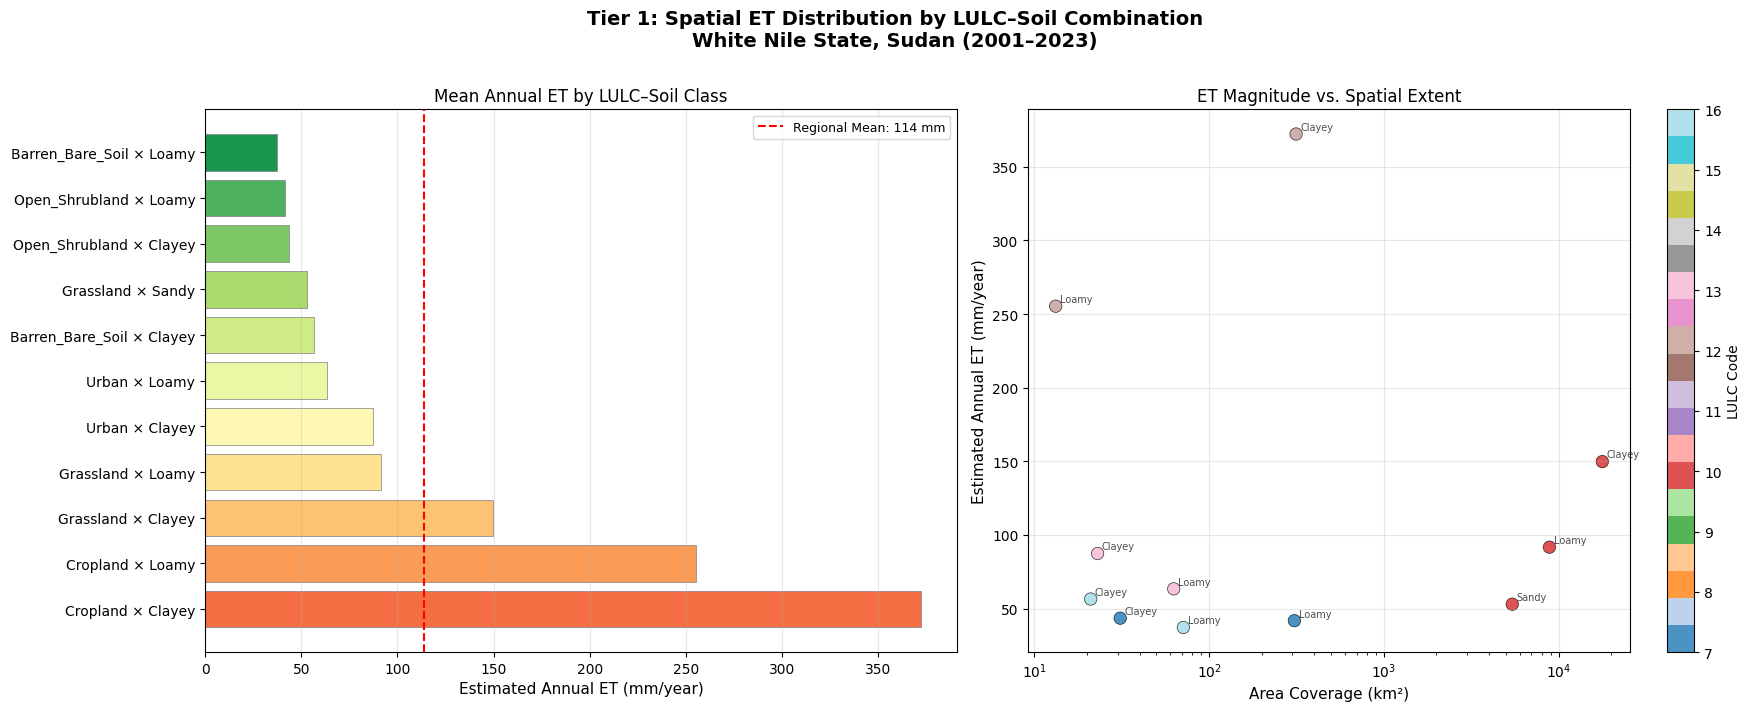

💾 Saved: F1_Spatial_ET_Bar_Scatter.png
📤 GEE Export started: ET_Annual_Mean_mm → Drive/ET_WhiteNile_Analysis/geotiff/
📤 GEE Export started: EF_Mean_2001_2023 → Drive/ET_WhiteNile_Analysis/geotiff/
📤 GEE Export started: LULC_Soil_Combined → Drive/ET_WhiteNile_Analysis/geotiff/
📤 GEE Export started: LULC_2022_500m → Drive/ET_WhiteNile_Analysis/geotiff/
📤 GEE Export started: Soil_Class_500m → Drive/ET_WhiteNile_Analysis/geotiff/

⏳ Check GEE Tasks tab (or run ee.batch.Task.list()) for export status.


In [4]:
# @title Notebook_2 Spatial analysis
# ║      NOTEBOOK 2 — TIER 1: SPATIAL ANALYSIS (LULC × SOIL ZONAL STATS)      ║
# ╚══════════════════════════════════════════════════════════════════════════════╝
# Paste this block into Cell 3

# ── 2.1  Resample LULC and Soil to MOD16 resolution (500 m) ─────────────────
# MODIS native projection: Sinusoidal, 500 m
modis_proj = MOD16.first().select('ET_mm').projection()

LULC_500m = LULC.reproject(crs=modis_proj, scale=500)
SOIL_500m  = SOIL.reproject(crs=modis_proj, scale=500)

# ── 2.2  Create the Combine raster: LULC × SOIL intersection ────────────────
# Encode as: combined_class = (LULC_class * 10) + SOIL_class
# This creates a unique integer per LULC–Soil combination
COMBINED = (LULC_500m.multiply(10)
                     .add(SOIL_500m)
                     .rename('LULC_Soil_Class')
                     .reproject(crs=modis_proj, scale=500))

# ── 2.3  Compute multi-year mean ET and EF (full period) ────────────────────
ET_mean_full  = MOD16.select('ET_mm').mean().clip(aoi_geometry)
PET_mean_full = MOD16.select('PET_mm').mean().clip(aoi_geometry)
EF_mean_full  = MOD16.select('EF').mean().clip(aoi_geometry)

# Annual ET total (multiply 8-day mean by 46 composites ≈ 365 days / 8 days)
ET_annual_approx = ET_mean_full.multiply(46).rename('ET_annual_mm')

# ── 2.4  Zonal statistics: Mean ET per LULC–Soil class ──────────────────────
def compute_zonal_stats_gee(et_image, combined_img, geometry, scale=500):
    """
    Compute mean ET and pixel count per LULC-Soil class.

    GEE CONSTRAINT: Reducer.group() with .combine() requires ≥3 bands
    and causes "duplicate output name" errors in many GEE API versions.

    SOLUTION: Class-by-class masking loop.
      - Mask ET image to pixels of each class
      - Call reduceRegion with simple mean() and count() separately
      - No grouped reducer needed — avoids ALL band-count / naming errors
    """
    # Get unique class codes present in the combined raster
    # Use a frequency histogram to find occupied classes efficiently
    freq = combined_img.reduceRegion(
        reducer=ee.Reducer.frequencyHistogram(),
        geometry=geometry,
        scale=scale,
        maxPixels=1e10,
        bestEffort=True
    ).getInfo()

    hist      = freq.get('LULC_Soil_Class', freq.get(list(freq.keys())[0], {}))
    all_codes = [int(float(k)) for k in hist.keys() if int(float(k)) > 0]

    groups = []
    for code in all_codes:
        mask      = combined_img.eq(int(code))
        et_masked = et_image.updateMask(mask)

        mean_val = et_masked.reduceRegion(
            reducer=ee.Reducer.mean(),
            geometry=geometry,
            scale=scale,
            maxPixels=1e10,
            bestEffort=True
        ).getInfo()

        cnt_val = et_masked.reduceRegion(
            reducer=ee.Reducer.count(),
            geometry=geometry,
            scale=scale,
            maxPixels=1e10,
            bestEffort=True
        ).getInfo()

        et_key    = list(mean_val.keys())[0] if mean_val else 'ET_mm'
        cnt_key   = list(cnt_val.keys())[0]  if cnt_val  else 'ET_mm'
        mean_et   = mean_val.get(et_key, None)
        pixel_cnt = cnt_val.get(cnt_key, 0) or 0

        if mean_et is not None:
            groups.append({
                'class':         code,
                'ET_mm_mean':    mean_et,
                'ET_mm_count':   pixel_cnt
            })

    return {'groups': groups}

raw_stats = compute_zonal_stats_gee(ET_mean_full, COMBINED, aoi_geometry)

# ── 2.5  Parse GEE output into a clean DataFrame ────────────────────────────
def parse_zonal_stats(raw_stats, et_col='ET_mm_mean', count_col='ET_mm_count'):
    rows = []
    groups = raw_stats.get('groups', [])
    for g in groups:
        code        = int(g['class'])
        lulc_val    = code // 10
        soil_val    = code % 10
        lulc_name   = LULC_CLASSES.get(lulc_val, f'Class_{lulc_val}')
        soil_name   = SOIL_CLASSES.get(soil_val, f'Soil_{soil_val}')
        mean_et     = g.get(et_col, None)
        pixel_count = g.get(count_col, 0)
        if mean_et is not None and pixel_count > 10:   # filter tiny fragments
            rows.append({
                'LULC_Code':   lulc_val,
                'Soil_Code':   soil_val,
                'LULC_Name':   lulc_name,
                'Soil_Name':   soil_name,
                'Combo_Code':  code,
                'Combo_Label': f'{lulc_name} × {soil_name}',
                'Mean_ET_8day_mm':    round(mean_et, 3),
                'Est_Annual_ET_mm':   round(mean_et * 46, 1),
                'Pixel_Count':        int(pixel_count),
                'Area_km2':           round(int(pixel_count) * 0.25, 2)  # 500m × 500m = 0.25 km²
            })
    df = pd.DataFrame(rows).sort_values('Mean_ET_8day_mm', ascending=False).reset_index(drop=True)
    df['Rank'] = df.index + 1

    # ── Post-filter: remove soil_0 artefacts ────────────────────────────────
    # Soil code 0 means masked/missing soil data (water, urban, edge pixels).
    # These are not real soil classes and must be excluded from analysis.
    before = len(df)
    df = df[df['Soil_Code'] != 0].reset_index(drop=True)
    df['Rank'] = df.index + 1
    removed = before - len(df)
    if removed > 0:
        print(f"  ℹ️  Removed {removed} soil_0 artefact row(s) "
              f"(masked pixels — water bodies / urban / AOI edges)")
    return df

df_spatial = parse_zonal_stats(raw_stats)
print(f"✅ Spatial zonal stats computed: {len(df_spatial)} LULC–Soil combinations")
print(df_spatial[['Combo_Label','Mean_ET_8day_mm','Est_Annual_ET_mm','Area_km2','Rank']].to_string(index=False))

# Save to CSV
df_spatial.to_csv(f'{OUTPUT_DIR}/tables/T1_Spatial_Zonal_Stats.csv', index=False)
print(f"\n💾 Saved: T1_Spatial_Zonal_Stats.csv")

# ── 2.6  Statistical Testing: ANOVA + Kruskal-Wallis across LULC classes ────
# Sample ET values per LULC class for statistical testing
# (GEE returns grouped means; we use pixel-level sampling for testing)
print("\n--- Sampling pixel-level ET values for statistical tests ---")

sample_pts = ET_mean_full.addBands(LULC_500m).addBands(SOIL_500m).sample(
    region=aoi_geometry,
    scale=500,
    numPixels=5000,
    seed=42,
    geometries=False
)

# Parse sample points — extract only the 3 needed properties by name
_features = sample_pts.getInfo()['features']
_rows_s = []
for feat in _features:
    props = feat.get('properties', {})
    # Band names match the order: ET_mm, LC_Type1, SoilClass
    _et   = props.get('ET_mm',    None)
    _lulc = props.get('LC_Type1', None)
    _soil = props.get('SoilClass',None)
    if _et is not None and _lulc is not None:
        _rows_s.append({'ET_mm': _et, 'LULC': _lulc, 'Soil': _soil})

sample_df = pd.DataFrame(_rows_s).dropna()
sample_df['LULC_Name'] = sample_df['LULC'].astype(int).map(LULC_CLASSES)
sample_df['Soil_Name'] = sample_df['Soil'].astype(int).map(SOIL_CLASSES)
print(f"  Sampled {len(sample_df)} valid pixels across "
      f"{sample_df['LULC_Name'].nunique()} LULC classes")
groups_by_lulc = [g['ET_mm'].values for _, g in sample_df.groupby('LULC_Name') if len(g) > 5]
if len(groups_by_lulc) >= 2:
    kw_stat, kw_p = kruskal(*groups_by_lulc)
    print(f"\n🔬 Kruskal-Wallis Test (ET across LULC classes):")
    print(f"   H-statistic = {kw_stat:.3f} | p-value = {kw_p:.6f}")
    if kw_p < 0.05:
        print("   ✅ Significant difference in ET across LULC classes (p < 0.05)")
    else:
        print("   ⚠️ No significant difference detected (p ≥ 0.05)")

# Tukey HSD post-hoc
tukey_data   = sample_df.dropna(subset=['ET_mm','LULC_Name'])
tukey_result = pairwise_tukeyhsd(tukey_data['ET_mm'], tukey_data['LULC_Name'], alpha=0.05)
tukey_df     = pd.DataFrame(data=tukey_result._results_table.data[1:],
                             columns=tukey_result._results_table.data[0])
tukey_df.to_csv(f'{OUTPUT_DIR}/tables/T2_Tukey_HSD_PostHoc.csv', index=False)
print(f"\n💾 Saved: T2_Tukey_HSD_PostHoc.csv")
print(tukey_df.to_string(index=False))

# ── 2.7  FIGURE 1: Bar chart — Mean Annual ET by LULC–Soil combination ──────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Tier 1: Spatial ET Distribution by LULC–Soil Combination\nWhite Nile State, Sudan (2001–2023)',
             fontsize=14, fontweight='bold', y=1.01)

# Left panel: horizontal bar chart of annual ET
colors_bar = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(df_spatial)))
ax = axes[0]
bars = ax.barh(df_spatial['Combo_Label'], df_spatial['Est_Annual_ET_mm'],
               color=colors_bar, edgecolor='grey', linewidth=0.5)
ax.set_xlabel('Estimated Annual ET (mm/year)', fontsize=11)
ax.set_title('Mean Annual ET by LULC–Soil Class', fontsize=12)
ax.axvline(df_spatial['Est_Annual_ET_mm'].mean(), color='red', linestyle='--',
           linewidth=1.5, label=f'Regional Mean: {df_spatial["Est_Annual_ET_mm"].mean():.0f} mm')
ax.legend(fontsize=9)
ax.grid(axis='x', alpha=0.3)

# Right panel: scatter — Area coverage vs. ET magnitude
ax2 = axes[1]
scatter = ax2.scatter(df_spatial['Area_km2'],
                      df_spatial['Est_Annual_ET_mm'],
                      s=80, c=df_spatial['LULC_Code'],
                      cmap='tab20', alpha=0.8, edgecolors='k', linewidths=0.5)
for _, row in df_spatial.iterrows():
    ax2.annotate(row['Soil_Name'], (row['Area_km2'], row['Est_Annual_ET_mm']),
                 fontsize=7, alpha=0.7, xytext=(3,3), textcoords='offset points')
ax2.set_xlabel('Area Coverage (km²)', fontsize=11)
ax2.set_ylabel('Estimated Annual ET (mm/year)', fontsize=11)
ax2.set_title('ET Magnitude vs. Spatial Extent', fontsize=12)
ax2.set_xscale('log')
ax2.grid(alpha=0.3)
plt.colorbar(scatter, ax=ax2, label='LULC Code')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/plots/F1_Spatial_ET_Bar_Scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print("💾 Saved: F1_Spatial_ET_Bar_Scatter.png")

# ── 2.8  Export GeoTIFF maps ─────────────────────────────────────────────────
def export_geotiff(image, description, folder, scale=500, region=None):
    """Export a GEE image to Google Drive as GeoTIFF."""
    if region is None:
        region = aoi_geometry
    task = ee.batch.Export.image.toDrive(
        image=image.clip(region),
        description=description,
        folder=folder,
        fileNamePrefix=description,
        region=region,
        scale=scale,
        crs='EPSG:4326',
        maxPixels=1e13,
        fileFormat='GeoTIFF'
    )
    task.start()
    print(f"📤 GEE Export started: {description} → Drive/{folder}/")
    return task

task1 = export_geotiff(ET_annual_approx,   'ET_Annual_Mean_mm',  'ET_WhiteNile_Analysis/geotiff')
task2 = export_geotiff(EF_mean_full,        'EF_Mean_2001_2023',  'ET_WhiteNile_Analysis/geotiff')
task3 = export_geotiff(COMBINED,            'LULC_Soil_Combined', 'ET_WhiteNile_Analysis/geotiff')
task4 = export_geotiff(LULC_500m,           'LULC_2022_500m',     'ET_WhiteNile_Analysis/geotiff')
task5 = export_geotiff(SOIL_500m,           'Soil_Class_500m',    'ET_WhiteNile_Analysis/geotiff')
print("\n⏳ Check GEE Tasks tab (or run ee.batch.Task.list()) for export status.")


aoi_geometry: already in session
Soil: OpenLandMap fallback
df_spatial loaded from T1 CSV (11 rows)

Session bootstrap complete — Notebook 3 ready

  Computing zonal stats: Dry (Nov–Feb)...
    → 12 classes found
  Computing zonal stats: Hot (Mar–May)...
    → 12 classes found
  Computing zonal stats: Wet (Jun–Oct)...
    → 12 classes found
✅ Seasonal zonal stats computed
💾 Saved: T3_Seasonal_Zonal_Stats.csv

--- Building annual ET time series (2001–2023) ---
    (processes one year at a time — ~30–60 sec total)
  LULC classes to process: [7, 10, 12, 13, 16]
  ✅ 2001: 5 LULC classes processed
  ✅ 2002: 5 LULC classes processed
  ✅ 2003: 5 LULC classes processed
  ✅ 2004: 5 LULC classes processed
  ✅ 2005: 5 LULC classes processed
  ✅ 2006: 5 LULC classes processed
  ✅ 2007: 5 LULC classes processed
  ✅ 2008: 5 LULC classes processed
  ✅ 2009: 5 LULC classes processed
  ✅ 2010: 5 LULC classes processed
  ✅ 2011: 5 LULC classes processed
  ✅ 2012: 5 LULC classes processed
  ✅ 2013: 5 LUL

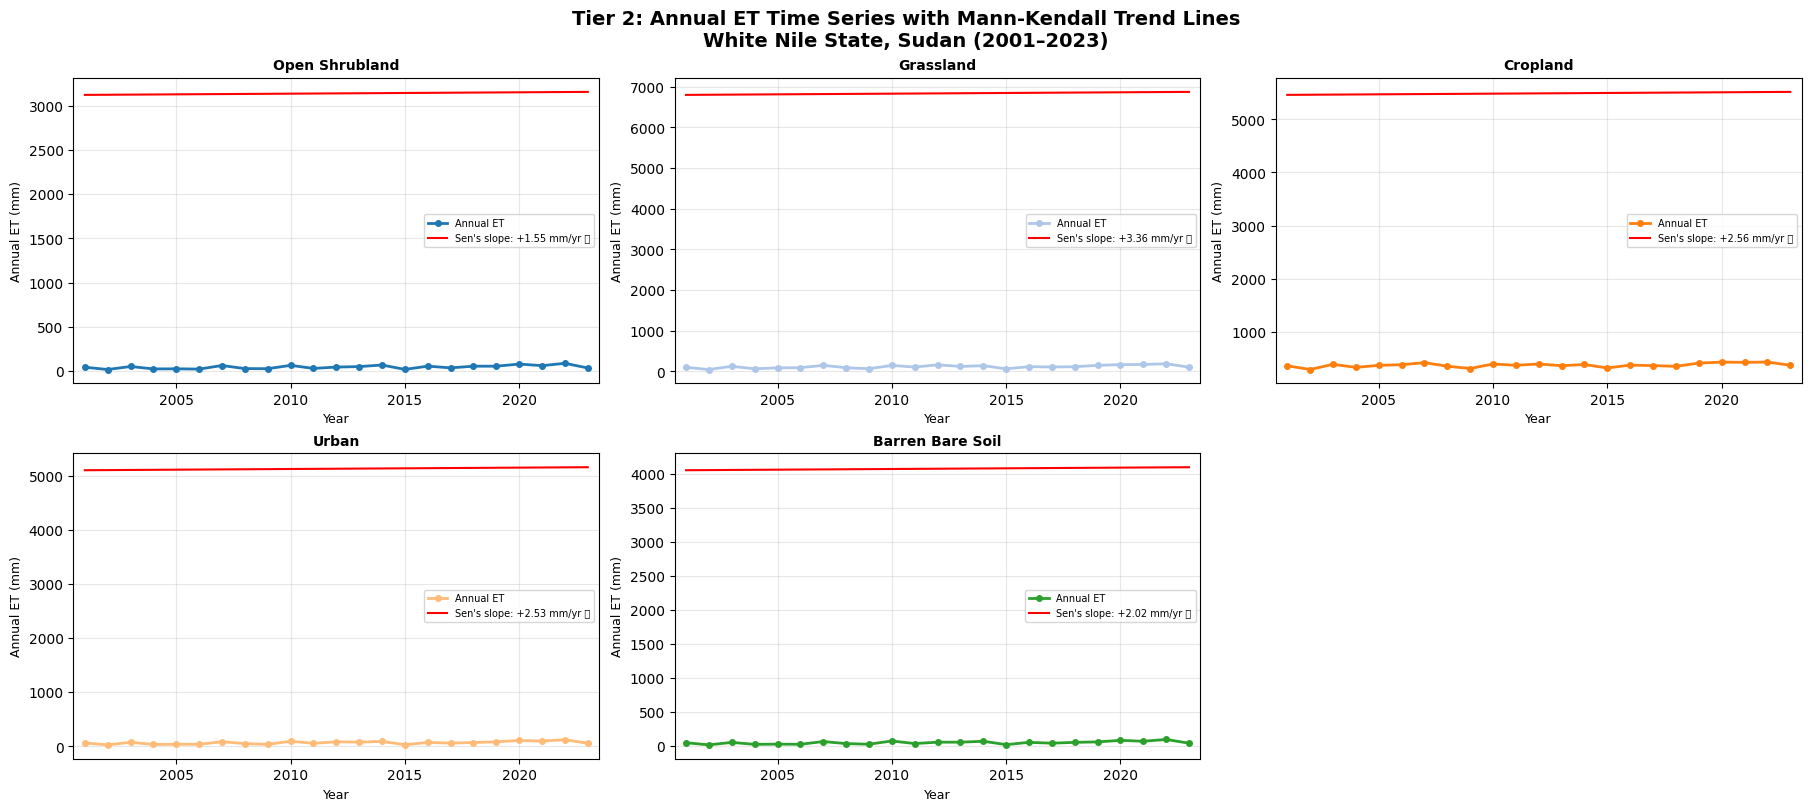

💾 Saved: F2_TimeSeries_MannKendall.png


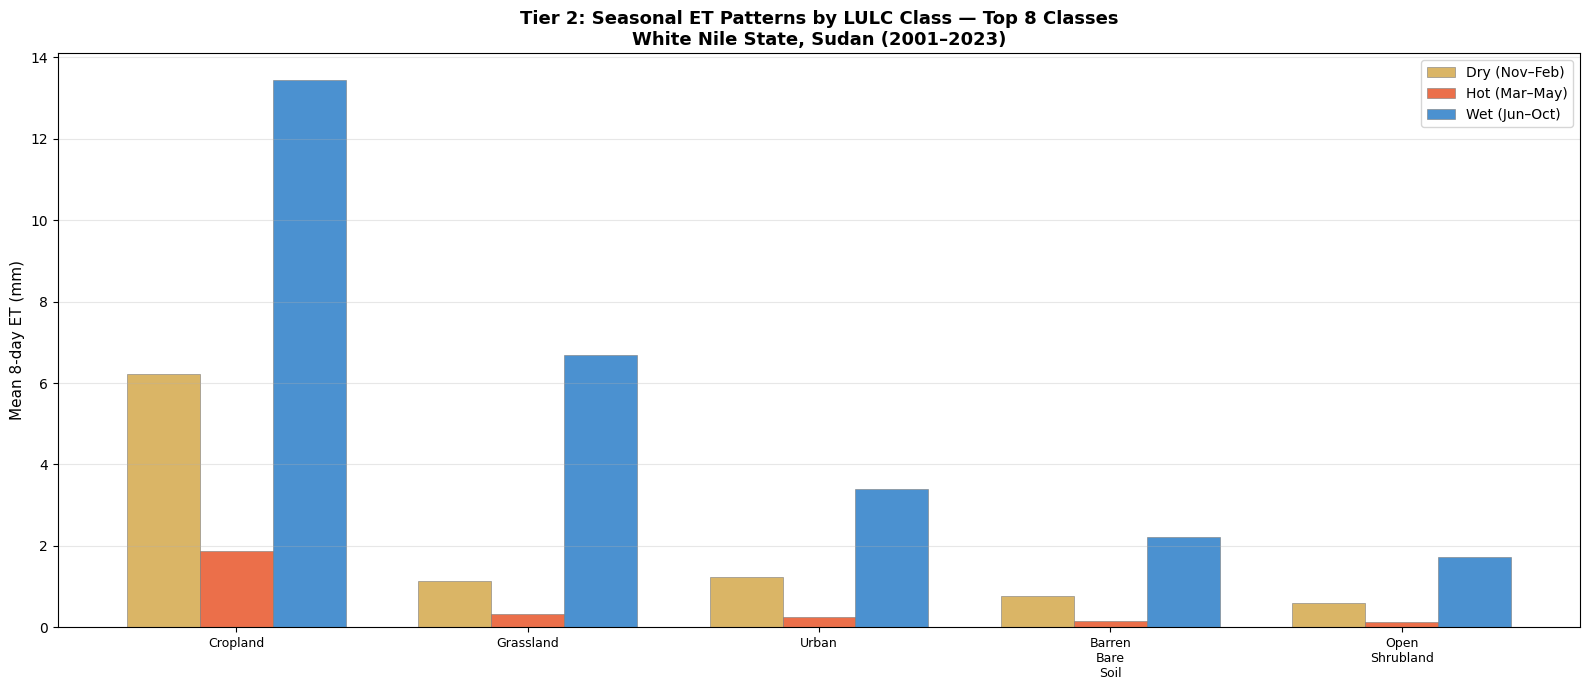

💾 Saved: F3_Seasonal_ET_Grouped_Bar.png
Export started: ET_Seasonal_Dry_Nov_Feb
Export started: ET_Seasonal_Hot_Mar_May
Export started: ET_Seasonal_Wet_Jun_Oct


In [6]:
# @title Notebook_3 Temporal analysis
# ║    NOTEBOOK 3 — TIER 2: TEMPORAL ANALYSIS (SEASONAL + TREND DETECTION)     ║
# ╚══════════════════════════════════════════════════════════════════════════════╝
# Paste this block into Cell 4

# Paste this block into Cell 4 of your Colab notebook.
# FULLY SELF-CONTAINED — safe to run after kernel restart.

# ── 3.0  Session bootstrap ────────────────────────────────────────────────────
import ee, os, json, glob, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pymannkendall as mk
from scipy.stats import kruskal
warnings.filterwarnings("ignore")

# -- GEE ping -----------------------------------------------------------------
try:
    ee.Number(1).getInfo()
except Exception:
    ee.Initialize(project="evapotranspiration-495110")
    print("GEE re-initialised")

# -- Constants ----------------------------------------------------------------
START_YEAR = 2001
END_YEAR   = 2023
START_DATE = f"{START_YEAR}-01-01"
END_DATE   = f"{END_YEAR}-12-31"
years      = list(range(START_YEAR, END_YEAR + 1))
OUTPUT_DIR = "/content/drive/MyDrive/ET_WhiteNile_Analysis"
os.makedirs(f"{OUTPUT_DIR}/tables", exist_ok=True)
os.makedirs(f"{OUTPUT_DIR}/plots",  exist_ok=True)

SEASONS = {
    "Dry":  [11, 12, 1, 2],    # Nov-Feb  (cool dry)
    "Hot":  [3, 4, 5],          # Mar-May  (hot dry)
    "Wet":  [6, 7, 8, 9, 10]   # Jun-Oct  (rainy)
}

LULC_CLASSES = {
    1:"Evergreen_Needleleaf_Forest", 2:"Evergreen_Broadleaf_Forest",
    3:"Deciduous_Needleleaf_Forest", 4:"Deciduous_Broadleaf_Forest",
    5:"Mixed_Forest",               6:"Closed_Shrubland",
    7:"Open_Shrubland",             8:"Woody_Savanna",
    9:"Savanna",                   10:"Grassland",
   11:"Permanent_Wetland",         12:"Cropland",
   13:"Urban",                     14:"Cropland_Natural_Mosaic",
   16:"Barren_Bare_Soil",          17:"Water",
}
SOIL_CLASSES = {0:"No_Data", 1:"Sandy", 2:"Loamy", 3:"Clayey"}

# -- AOI: GEE asset → shapefile → GAUL ---------------------------------------
try:
    _ = aoi_geometry.getInfo()
    print("aoi_geometry: already in session")
except NameError:
    try:
        _asset       = "projects/ee-abdoyanes2016/assets/White_NILe_State"
        AOI          = ee.FeatureCollection(_asset)
        aoi_geometry = AOI.geometry()
        aoi_geometry.bounds().getInfo()
        print(f"aoi_geometry: GEE asset ({_asset})")
    except Exception as _ea:
        _shp = (glob.glob("/tmp/*/s_area.shp") + glob.glob("/tmp/s_area.shp") +
                glob.glob("/content/s_area.shp"))
        if _shp:
            import geopandas as gpd
            _gdf         = gpd.read_file(_shp[0]).to_crs("EPSG:4326")
            AOI          = ee.FeatureCollection(json.loads(_gdf.to_json()))
            aoi_geometry = AOI.geometry()
            print(f"aoi_geometry: shapefile ({_shp[0]})")
        else:
            _g = ee.FeatureCollection("FAO/GAUL/2015/level1")
            AOI = _g.filter(ee.Filter.And(
                      ee.Filter.eq("ADM0_NAME", "Sudan"),
                      ee.Filter.eq("ADM1_NAME", "White Nile")))
            aoi_geometry = AOI.geometry()
            print("aoi_geometry: GAUL fallback")

# -- MOD16 scaled collection --------------------------------------------------
def _qc_scale(img):
    qc  = img.select("ET_QC")
    ok  = qc.bitwiseAnd(3).lte(1)
    et  = img.select("ET").multiply(0.1).updateMask(ok).rename("ET_mm")
    pet = img.select("PET").multiply(0.1).updateMask(ok).rename("PET_mm")
    ef  = et.divide(pet).rename("EF")
    return img.addBands(et).addBands(pet).addBands(ef).copyProperties(
               img, ["system:time_start"])

MOD16 = (ee.ImageCollection("MODIS/061/MOD16A2GF")
           .filterDate(START_DATE, END_DATE)
           .filterBounds(aoi_geometry)
           .map(_qc_scale))

# -- LULC and Soil rasters (500 m) -------------------------------------------
modis_proj = MOD16.first().select("ET_mm").projection()

LULC_500m = (ee.ImageCollection("MODIS/061/MCD12Q1")
               .filterDate("2022-01-01", "2022-12-31")
               .first().select("LC_Type1").clip(aoi_geometry)
               .reproject(crs=modis_proj, scale=500))

# Soil: GEE asset → OpenLandMap → static fallback
_soil_ok = False
try:
    _sand = (ee.Image("ISDASOIL/Africa/v1/sand_content_0_20cm")
               .select("mean_0_20").clip(aoi_geometry))
    _clay = (ee.Image("ISDASOIL/Africa/v1/clay_content_0_20cm")
               .select("mean_0_20").clip(aoi_geometry))
    _sand.reduceRegion(ee.Reducer.mean(), aoi_geometry.centroid(30), 500,
                       maxPixels=10).getInfo()
    _valid = _sand.mask().And(_clay.mask())
    SOIL_500m = (ee.Image(2).where(_sand.gte(70), 1).where(_clay.gte(35), 3)
                   .rename("SoilClass").updateMask(_valid).clip(aoi_geometry)
                   .reproject(crs=modis_proj, scale=500))
    _soil_ok = True
    print("Soil: iSDAsoil v1")
except Exception:
    pass

if not _soil_ok:
    try:
        _sand2 = (ee.Image("OpenLandMap/SOL/SOL_SAND-WFRACTION_USDA-3A1A1A_M/v02")
                    .expression("(b('b0')+b('b10'))/2").rename("sand"))
        _clay2 = (ee.Image("OpenLandMap/SOL/SOL_CLAY-WFRACTION_USDA-3A1A1A_M/v02")
                    .expression("(b('b0')+b('b10'))/2").rename("clay"))
        SOIL_500m = (ee.Image(2).where(_sand2.gte(70), 1).where(_clay2.gte(35), 3)
                       .rename("SoilClass").clip(aoi_geometry)
                       .reproject(crs=modis_proj, scale=500))
        _soil_ok = True
        print("Soil: OpenLandMap fallback")
    except Exception:
        _lon = ee.Image.pixelLonLat().select("longitude")
        SOIL_500m = (ee.Image(2).where(_lon.gte(30.5).And(_lon.lte(32.0)), 3)
                       .where(_lon.gt(32.0), 1).where(_lon.lt(30.5), 1)
                       .rename("SoilClass").clip(aoi_geometry)
                       .reproject(crs=modis_proj, scale=500))
        print("Soil: static zone approximation")

# -- COMBINED raster ----------------------------------------------------------
COMBINED = (LULC_500m.multiply(10).add(SOIL_500m)
              .rename("LULC_Soil_Class")
              .reproject(crs=modis_proj, scale=500))

# -- Helper functions (from Notebook 2) ---------------------------------------
def compute_zonal_stats_gee(et_image, combined_img, geometry, scale=500):
    """Per-class masking — avoids GEE grouped reducer band-count errors."""
    freq = combined_img.reduceRegion(
        reducer=ee.Reducer.frequencyHistogram(),
        geometry=geometry, scale=scale,
        maxPixels=1e10, bestEffort=True
    ).getInfo()
    _key   = "LULC_Soil_Class" if "LULC_Soil_Class" in freq else list(freq.keys())[0]
    hist   = freq.get(_key, {})
    codes  = [int(float(k)) for k in hist.keys() if int(float(k)) > 0]
    groups = []
    for code in codes:
        mask     = combined_img.eq(int(code))
        masked   = et_image.updateMask(mask)
        mean_v   = masked.reduceRegion(ee.Reducer.mean(),   geometry, scale,
                                       maxPixels=1e10, bestEffort=True).getInfo()
        cnt_v    = masked.reduceRegion(ee.Reducer.count(),  geometry, scale,
                                       maxPixels=1e10, bestEffort=True).getInfo()
        et_key   = list(mean_v.keys())[0] if mean_v else "ET_mm"
        cnt_key  = list(cnt_v.keys())[0]  if cnt_v  else "ET_mm"
        mean_et  = mean_v.get(et_key, None)
        px_count = cnt_v.get(cnt_key, 0) or 0
        if mean_et is not None:
            groups.append({"class": code, "ET_mm_mean": mean_et,
                           "ET_mm_count": px_count})
    return {"groups": groups}

def parse_zonal_stats(raw_stats, et_col="ET_mm_mean", count_col="ET_mm_count"):
    rows   = []
    groups = raw_stats.get("groups", [])
    for g in groups:
        code       = int(g["class"])
        lulc_val   = code // 10
        soil_val   = code % 10
        mean_et    = g.get(et_col,    None)
        pixel_cnt  = g.get(count_col, 0)
        if mean_et is not None and pixel_cnt > 10 and soil_val != 0:
            rows.append({
                "LULC_Code":      lulc_val,
                "Soil_Code":      soil_val,
                "LULC_Name":      LULC_CLASSES.get(lulc_val, f"Class_{lulc_val}"),
                "Soil_Name":      SOIL_CLASSES.get(soil_val, f"Soil_{soil_val}"),
                "Combo_Code":     code,
                "Combo_Label":    (f"{LULC_CLASSES.get(lulc_val,f'Class_{lulc_val}')} x "
                                   f"{SOIL_CLASSES.get(soil_val,f'Soil_{soil_val}')}"),
                "Mean_ET_8day_mm":  round(mean_et, 3),
                "Est_Annual_ET_mm": round(mean_et * 46, 1),
                "Pixel_Count":      int(pixel_cnt),
                "Area_km2":         round(int(pixel_cnt) * 0.25, 2),
            })
    df = pd.DataFrame(rows).sort_values("Mean_ET_8day_mm",
                                         ascending=False).reset_index(drop=True)
    df["Rank"] = df.index + 1
    return df

def export_geotiff(image, description, folder, scale=500, region=None):
    if region is None:
        region = aoi_geometry
    task = ee.batch.Export.image.toDrive(
        image=image.clip(region), description=description,
        folder=folder, fileNamePrefix=description,
        region=region, scale=scale, crs="EPSG:4326",
        maxPixels=1e13, fileFormat="GeoTIFF"
    )
    task.start()
    print(f"Export started: {description}")
    return task

# -- Load df_spatial from T1 CSV (preferred) or recompute --------------------
_t1_path = f"{OUTPUT_DIR}/tables/T1_Spatial_Zonal_Stats.csv"
if os.path.exists(_t1_path):
    df_spatial = pd.read_csv(_t1_path)
    print(f"df_spatial loaded from T1 CSV ({len(df_spatial)} rows)")
else:
    print("T1 CSV not found — recomputing df_spatial from GEE...")
    ET_mean_full = MOD16.select("ET_mm").mean().clip(aoi_geometry)
    _raw = compute_zonal_stats_gee(ET_mean_full, COMBINED, aoi_geometry)
    df_spatial = parse_zonal_stats(_raw)
    df_spatial.to_csv(_t1_path, index=False)
    print(f"df_spatial recomputed: {len(df_spatial)} classes")

print("\nSession bootstrap complete — Notebook 3 ready\n")


# ── 3.1  Seasonal ET computation ─────────────────────────────────────────────
def get_seasonal_et(collection, months, start_yr, end_yr, geometry):
    """
    Compute mean ET for a given list of months across all years.
    CRITICAL FIX: calendarRange(start, end) returns EMPTY when start > end.
    The Dry season [11,12,1,2] crosses the year boundary (Nov=11 > Feb=2),
    so we OR-chain individual monthly filters instead.
    """
    _mf = [ee.Filter.calendarRange(m, m, "month") for m in months]
    _cf = _mf[0]
    for _f in _mf[1:]:
        _cf = ee.Filter.Or(_cf, _f)
    return collection.filter(_cf).select("ET_mm").mean().clip(geometry)
ET_dry = get_seasonal_et(MOD16, SEASONS['Dry'], START_YEAR, END_YEAR, aoi_geometry)
ET_hot = get_seasonal_et(MOD16, SEASONS['Hot'], START_YEAR, END_YEAR, aoi_geometry)
ET_wet = get_seasonal_et(MOD16, SEASONS['Wet'], START_YEAR, END_YEAR, aoi_geometry)

# Zonal stats per season per LULC–Soil class
def seasonal_zonal(et_img, label):
    """Compute zonal stats per LULC-Soil class for one season."""
    print(f"  Computing zonal stats: {label}...")
    raw = compute_zonal_stats_gee(et_img, COMBINED, aoi_geometry, scale=500)
    df  = parse_zonal_stats(raw)
    df['Season'] = label
    print(f"    → {len(df)} classes found")
    return df

df_dry = seasonal_zonal(ET_dry, 'Dry (Nov–Feb)')
df_hot = seasonal_zonal(ET_hot, 'Hot (Mar–May)')
df_wet = seasonal_zonal(ET_wet, 'Wet (Jun–Oct)')

df_seasonal = pd.concat([df_dry, df_hot, df_wet], ignore_index=True)
df_seasonal.to_csv(f'{OUTPUT_DIR}/tables/T3_Seasonal_Zonal_Stats.csv', index=False)
print("✅ Seasonal zonal stats computed")
print("💾 Saved: T3_Seasonal_Zonal_Stats.csv")

# ── 3.2  Annual ET time series per LULC class ────────────────────────────────
# FIX: Replaced grouped reducer (causes ≥3 band error) with per-class
# masking loop. One reduceRegion call per year per LULC class.
print("\n--- Building annual ET time series (2001–2023) ---")
print("    (processes one year at a time — ~30–60 sec total)")

# Get LULC classes actually present in AOI from df_spatial
lulc_codes_present = sorted(df_spatial['LULC_Code'].unique().tolist())
print(f"  LULC classes to process: {lulc_codes_present}")

rows_ts = []
for year in years:
    yr_et = (MOD16.filter(ee.Filter.calendarRange(year, year, 'year'))
                  .select('ET_mm')
                  .mean()
                  .clip(aoi_geometry))

    for lulc_code in lulc_codes_present:
        lulc_mask  = LULC_500m.eq(int(lulc_code))
        et_masked  = yr_et.updateMask(lulc_mask)

        try:
            mean_val = et_masked.reduceRegion(
                reducer=ee.Reducer.mean(),
                geometry=aoi_geometry,
                scale=500,
                maxPixels=1e10,
                bestEffort=True
            ).getInfo()

            et_val = mean_val.get('ET_mm', None)
            if et_val is not None:
                rows_ts.append({
                    'Year':            year,
                    'LULC_Code':       lulc_code,
                    'LULC_Name':       LULC_CLASSES.get(lulc_code, f'Class_{lulc_code}'),
                    'Mean_ET_8day_mm': round(et_val, 3),
                    'Est_Annual_ET_mm': round(et_val * 46, 1)
                })
        except Exception as _e:
            print(f"    ⚠️  Year {year}, LULC {lulc_code} skipped: {_e}")
            continue

    print(f"  ✅ {year}: {len([r for r in rows_ts if r['Year']==year])} LULC classes processed")

df_timeseries = pd.DataFrame(rows_ts)
df_timeseries.to_csv(f'{OUTPUT_DIR}/tables/T4_Annual_ET_TimeSeries.csv', index=False)
print(f"✅ Annual time series built: {len(df_timeseries)} records")
print("💾 Saved: T4_Annual_ET_TimeSeries.csv")

# ── 3.3  Mann-Kendall Trend Test per LULC class ──────────────────────────────
print("\n--- Mann-Kendall Trend Analysis ---")
trend_results = []

for lulc_name, grp in df_timeseries.groupby('LULC_Name'):
    grp_sorted = grp.sort_values('Year')
    if len(grp_sorted) < 5:
        continue
    series = grp_sorted['Est_Annual_ET_mm'].values
    result = mk.original_test(series)

    trend_results.append({
        'LULC_Name':        lulc_name,
        'MK_Trend':         result.trend,
        'MK_p_value':       round(result.p, 4),
        'MK_Tau':           round(result.Tau, 3),
        'Sens_Slope_mm_yr': round(result.slope, 3),
        'Sens_Intercept':   round(result.intercept, 2),
        'Significant':      'Yes' if result.p < 0.05 else 'No',
        'n_years':          len(grp_sorted)
    })
    print(f"  {lulc_name:35s} | Trend: {result.trend:11s} | p={result.p:.4f} | "
          f"Sen's slope: {result.slope:.2f} mm/yr | Sig: {'✅' if result.p < 0.05 else '—'}")

df_trends = pd.DataFrame(trend_results)
df_trends.to_csv(f'{OUTPUT_DIR}/tables/T5_MannKendall_Trends.csv', index=False)
print(f"\n💾 Saved: T5_MannKendall_Trends.csv")

# ── 3.4  FIGURE 2: Time series with trend lines ──────────────────────────────
lulc_names_present = df_timeseries['LULC_Name'].unique()
n_classes = len(lulc_names_present)
cols_ts = 3
rows_ts_plot = (n_classes + cols_ts - 1) // cols_ts

fig, axes = plt.subplots(rows_ts_plot, cols_ts,
                         figsize=(18, rows_ts_plot * 4),
                         constrained_layout=True)
axes_flat = axes.flatten()

palette = sns.color_palette('tab20', n_classes)

for i, lulc_name in enumerate(lulc_names_present):
    ax    = axes_flat[i]
    grp   = df_timeseries[df_timeseries['LULC_Name'] == lulc_name].sort_values('Year')
    trend = df_trends[df_trends['LULC_Name'] == lulc_name]

    ax.plot(grp['Year'], grp['Est_Annual_ET_mm'],
            color=palette[i], linewidth=2, marker='o', markersize=4, label='Annual ET')

    if not trend.empty:
        slope   = trend['Sens_Slope_mm_yr'].values[0]
        intcept = trend['Sens_Intercept'].values[0]
        trend_y = [slope * yr + intcept for yr in grp['Year']]
        sig     = trend['Significant'].values[0]
        style   = '-' if sig == 'Yes' else '--'
        lbl     = f"Sen's slope: {slope:+.2f} mm/yr {'✅' if sig=='Yes' else ''}"
        ax.plot(grp['Year'], trend_y, color='red', linewidth=1.5,
                linestyle=style, label=lbl)

    ax.set_title(lulc_name.replace('_', ' '), fontsize=10, fontweight='bold')
    ax.set_xlabel('Year', fontsize=9)
    ax.set_ylabel('Annual ET (mm)', fontsize=9)
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)
    ax.set_xlim(START_YEAR - 0.5, END_YEAR + 0.5)

# Hide unused subplots
for j in range(i + 1, len(axes_flat)):
    axes_flat[j].set_visible(False)

fig.suptitle('Tier 2: Annual ET Time Series with Mann-Kendall Trend Lines\n'
             'White Nile State, Sudan (2001–2023)', fontsize=14, fontweight='bold')
plt.savefig(f'{OUTPUT_DIR}/plots/F2_TimeSeries_MannKendall.png', dpi=150, bbox_inches='tight')
plt.show()
print("💾 Saved: F2_TimeSeries_MannKendall.png")

# ── 3.5  FIGURE 3: Seasonal box plots ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 7))

# Pivot for grouped plotting
top_classes = (df_spatial.groupby('LULC_Name')['Est_Annual_ET_mm']
                          .mean()
                          .nlargest(8)
                          .index.tolist())
df_seas_top = df_seasonal[df_seasonal['LULC_Name'].isin(top_classes)]

season_order  = ['Dry (Nov–Feb)', 'Hot (Mar–May)', 'Wet (Jun–Oct)']
season_colors = {'Dry (Nov–Feb)': '#d4a84b',    # sandy amber
                 'Hot (Mar–May)': '#e8562a',     # burnt orange
                 'Wet (Jun–Oct)': '#2b7ec8'}     # deep blue

x = np.arange(len(top_classes))
width = 0.25
for j, season in enumerate(season_order):
    seas_data = df_seas_top[df_seas_top['Season'] == season]
    et_vals = [seas_data[seas_data['LULC_Name'] == cls]['Mean_ET_8day_mm'].values
               for cls in top_classes]
    et_means = [v[0] if len(v) > 0 else 0 for v in et_vals]
    ax.bar(x + j * width, et_means, width, label=season,
           color=season_colors[season], alpha=0.85, edgecolor='grey', linewidth=0.5)

ax.set_xticks(x + width)
ax.set_xticklabels([c.replace('_', '\n') for c in top_classes], fontsize=9)
ax.set_ylabel('Mean 8-day ET (mm)', fontsize=11)
ax.set_title('Tier 2: Seasonal ET Patterns by LULC Class — Top 8 Classes\n'
             'White Nile State, Sudan (2001–2023)', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/plots/F3_Seasonal_ET_Grouped_Bar.png', dpi=150, bbox_inches='tight')
plt.show()
print("💾 Saved: F3_Seasonal_ET_Grouped_Bar.png")

# Export seasonal ET maps
task6 = export_geotiff(ET_dry, 'ET_Seasonal_Dry_Nov_Feb',  'ET_WhiteNile_Analysis/geotiff')
task7 = export_geotiff(ET_hot, 'ET_Seasonal_Hot_Mar_May',  'ET_WhiteNile_Analysis/geotiff')
task8 = export_geotiff(ET_wet, 'ET_Seasonal_Wet_Jun_Oct',  'ET_WhiteNile_Analysis/geotiff')

Processing 11 LULC-Soil classes...
  [01/11] Code  123 (Cropland x Clayey): ET=372.2 mm, P=390.4 mm, Surplus=18.2 mm
  [02/11] Code  122 (Cropland x Loamy): ET=254.9 mm, P=325.7 mm, Surplus=70.8 mm
  [03/11] Code  103 (Grassland x Clayey): ET=149.8 mm, P=387.7 mm, Surplus=238.2 mm
  [04/11] Code  102 (Grassland x Loamy): ET=92.3 mm, P=325.2 mm, Surplus=237.5 mm
  [05/11] Code  133 (Urban x Clayey): ET=87.4 mm, P=288.9 mm, Surplus=197.2 mm
  [06/11] Code  132 (Urban x Loamy): ET=63.0 mm, P=237.3 mm, Surplus=158.9 mm
  [07/11] Code  163 (Barren_Bare_Soil x Clayey): ET=56.5 mm, P=243.6 mm, Surplus=171.5 mm
  [08/11] Code  101 (Grassland x Sandy): ET=53.0 mm, P=279.3 mm, Surplus=242.6 mm
  [09/11] Code   73 (Open_Shrubland x Clayey): ET=43.5 mm, P=188.0 mm, Surplus=144.1 mm
  [10/11] Code   72 (Open_Shrubland x Loamy): ET=41.8 mm, P=180.0 mm, Surplus=142.3 mm
  [11/11] Code  162 (Barren_Bare_Soil x Loamy): ET=44.4 mm, P=179.4 mm, Surplus=153.3 mm
✅ Water balance table computed
💾 Saved: T6_

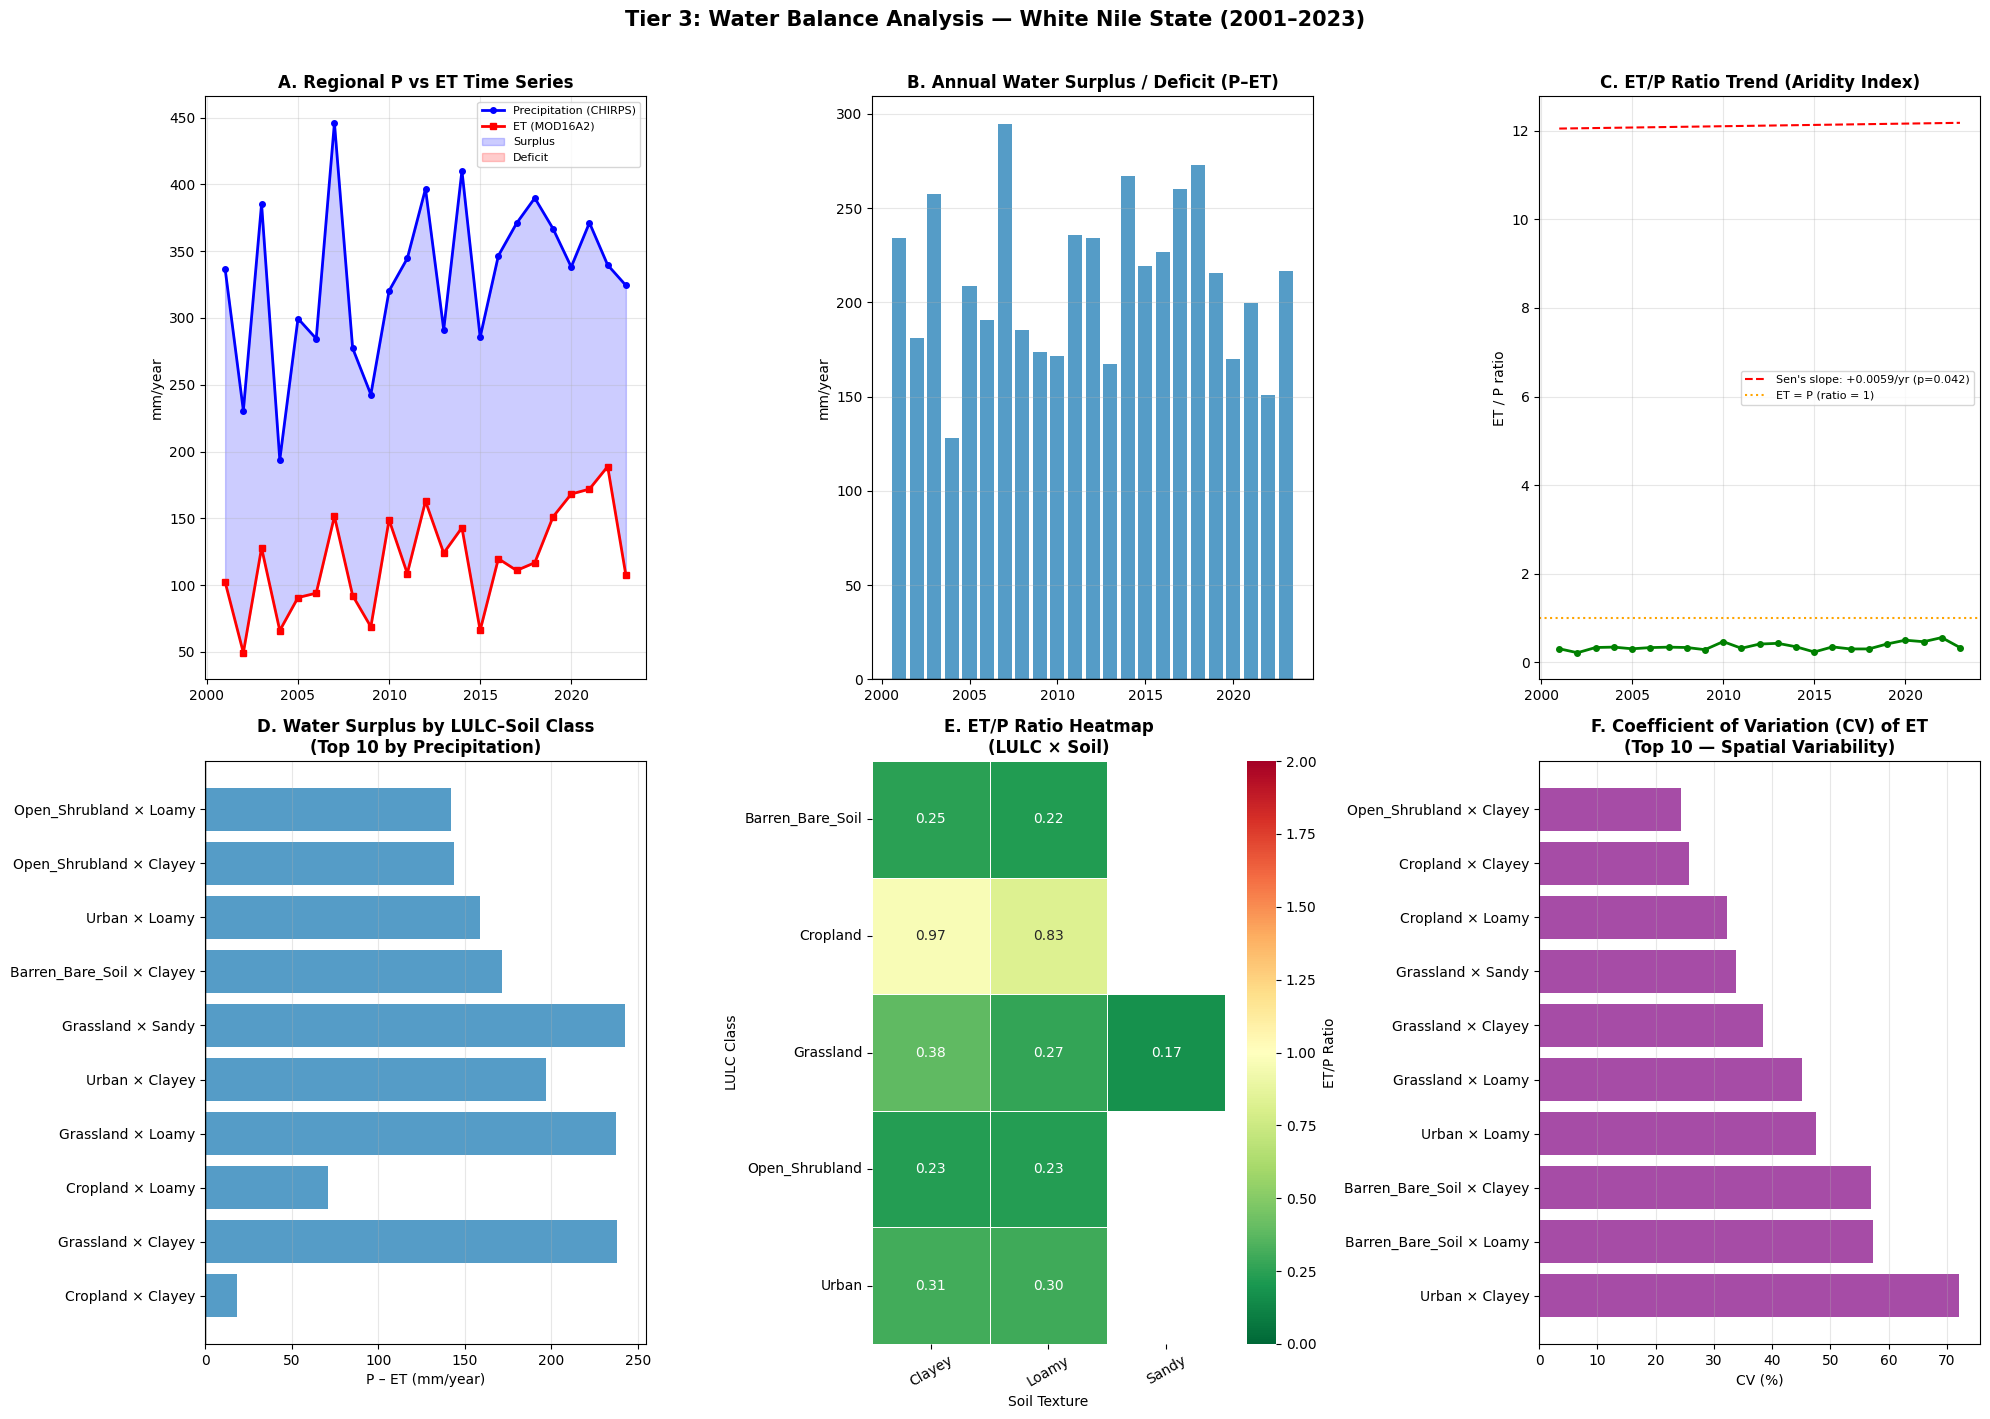

💾 Saved: F4_WaterBalance_Dashboard.png
Export started: WaterBalance_Surplus_mm
Export started: WaterBalance_Deficit_mm
Export started: Aridity_Index_ET_over_P
Export started: Precip_Annual_Mean_CHIRPS_mm


In [7]:
# @title Notebook_4 Hydrological Integration
# ║       NOTEBOOK 4 — TIER 3: HYDROLOGICAL INTEGRATION (WATER BALANCE)       ║
# ╚══════════════════════════════════════════════════════════════════════════════╝
# Paste this block into Cell 5

# ── 4.1  Annual Precipitation from CHIRPS ────────────────────────────────────
def get_annual_precip(year):
    """Sum daily CHIRPS precipitation to annual total."""
    return (CHIRPS.filter(ee.Filter.calendarRange(year, year, 'year'))
                  .sum()
                  .clip(aoi_geometry)
                  .rename('Precip_mm'))

# Multi-year mean precipitation
precip_annual_mean = (ee.ImageCollection(
    [get_annual_precip(y) for y in years]
).mean().clip(aoi_geometry))

# ── 4.2  Water Balance Components ────────────────────────────────────────────
# P - ET = Surplus (positive) or Deficit (negative)
# Surplus: water potentially available for runoff / recharge
# Deficit: water stress / unmet evaporative demand

water_surplus  = precip_annual_mean.subtract(ET_annual_approx).rename('Water_Surplus_mm')
water_deficit  = PET_mean_full.multiply(46).subtract(ET_annual_approx).rename('Water_Deficit_mm')
aridity_index  = ET_annual_approx.divide(precip_annual_mean).rename('Aridity_Index_ET_P')

# ── 4.3  Zonal water balance per LULC–Soil class ─────────────────────────────
# GEE HARD CONSTRAINT: ee.Reducer.group() requires that the grouping band is
# the LAST band in the image AND that no combined reducers are used together
# with group(). The safest, most reliable approach is to avoid grouped reducers
# entirely and instead iterate over each unique LULC-Soil class in Python,
# masking the image to that class and calling reduceRegion independently.
# This avoids ALL GEE reducer chaining / ordering errors completely.

# -- Water balance image stack (no group band embedded) -----------------------
wb_stack = (ET_annual_approx
              .addBands(precip_annual_mean.rename('Precip_mm'))
              .addBands(water_surplus)
              .addBands(water_deficit)
              .addBands(aridity_index))

# -- Get unique LULC-Soil class codes present in the AOI ---------------------
# Use the df_spatial table already computed in Notebook 2 (Tier 1)
# which contains all valid combo codes with pixel_count > 10.
unique_codes = df_spatial['Combo_Code'].tolist()
print(f"Processing {len(unique_codes)} LULC-Soil classes...")

wb_rows = []
for i, code in enumerate(unique_codes):
    lulc_val = code // 10
    soil_val = code % 10

    # Mask the water balance stack to pixels belonging to this class only
    class_mask = COMBINED.eq(int(code))
    wb_masked  = wb_stack.updateMask(class_mask)

    # reduceRegion with mean + stdDev as SEPARATE calls (no grouping needed)
    try:
        mean_vals = wb_masked.reduceRegion(
            reducer=ee.Reducer.mean(),
            geometry=aoi_geometry,
            scale=500,
            maxPixels=1e10,
            bestEffort=True
        ).getInfo()

        std_vals = wb_masked.reduceRegion(
            reducer=ee.Reducer.stdDev(),
            geometry=aoi_geometry,
            scale=500,
            maxPixels=1e10,
            bestEffort=True
        ).getInfo()

        cnt_vals = wb_masked.select('ET_annual_mm').reduceRegion(
            reducer=ee.Reducer.count(),
            geometry=aoi_geometry,
            scale=500,
            maxPixels=1e10,
            bestEffort=True
        ).getInfo()

        pixel_n = cnt_vals.get('ET_annual_mm', 0) or 0
        if pixel_n < 10:
            continue

        et_mean    = mean_vals.get('ET_annual_mm',      0) or 0
        sd_et      = std_vals.get('ET_annual_mm',       0) or 0
        p_mean     = mean_vals.get('Precip_mm',         0) or 0
        sd_p       = std_vals.get('Precip_mm',          0) or 0
        surp_mean  = mean_vals.get('Water_Surplus_mm',  0) or 0
        defic_mean = mean_vals.get('Water_Deficit_mm',  0) or 0
        ai_mean    = mean_vals.get('Aridity_Index_ET_P',0) or 0

        wb_rows.append({
            'LULC_Name':        LULC_CLASSES.get(lulc_val, f'Class_{lulc_val}'),
            'Soil_Name':        SOIL_CLASSES.get(soil_val, f'Soil_{soil_val}'),
            'Combo_Code':       code,
            'Pixel_Count':      int(pixel_n),
            'Area_km2':         round(int(pixel_n) * 0.25, 1),
            'Mean_ET_mm':       round(et_mean,    1),
            'Mean_Precip_mm':   round(p_mean,     1),
            'Water_Surplus_mm': round(surp_mean,  1),
            'Water_Deficit_mm': round(defic_mean, 1),
            'ET_Precip_Ratio':  round(ai_mean,    3),
            'SD_ET_mm':         round(sd_et,      1),
            'SD_Precip_mm':     round(sd_p,       1),
        })
        print(f"  [{i+1:02d}/{len(unique_codes)}] Code {code:4d} "
              f"({LULC_CLASSES.get(lulc_val,'?')} x {SOIL_CLASSES.get(soil_val,'?')}): "
              f"ET={et_mean:.1f} mm, P={p_mean:.1f} mm, "
              f"Surplus={surp_mean:.1f} mm")

    except Exception as ex:
        print(f"  ⚠️  Code {code} skipped: {ex}")
        continue

df_waterbalance = (pd.DataFrame(wb_rows)
                     .sort_values('Water_Surplus_mm', ascending=False)
                     .reset_index(drop=True))

# CV = SD / Mean × 100
df_waterbalance['CV_ET_pct'] = round(
    df_waterbalance['SD_ET_mm'] / df_waterbalance['Mean_ET_mm'].replace(0, np.nan) * 100, 1)

df_waterbalance.to_csv(f'{OUTPUT_DIR}/tables/T6_WaterBalance_by_Class.csv', index=False)
print("✅ Water balance table computed")
print("💾 Saved: T6_WaterBalance_by_Class.csv")
print(df_waterbalance.to_string(index=False))

# ── 4.4  Annual P and ET time series for trend comparison ────────────────────
precip_ts_rows = []
for year in years:
    precip_yr = (CHIRPS.filter(ee.Filter.calendarRange(year, year, 'year'))
                        .sum()
                        .reduceRegion(
                            reducer=ee.Reducer.mean(),
                            geometry=aoi_geometry,
                            scale=5000,
                            maxPixels=1e10,
                            bestEffort=True
                        ).getInfo())
    et_yr = (MOD16.filter(ee.Filter.calendarRange(year, year, 'year'))
                   .select('ET_mm')
                   .mean()
                   .multiply(46)
                   .reduceRegion(
                       reducer=ee.Reducer.mean(),
                       geometry=aoi_geometry,
                       scale=500,
                       maxPixels=1e10,
                       bestEffort=True
                   ).getInfo())
    precip_ts_rows.append({
        'Year':       year,
        'Precip_mm':  round(precip_yr.get('precipitation', 0), 1),
        'ET_mm':      round(et_yr.get('ET_mm', 0) if et_yr.get('ET_mm') else 0, 1)
    })

df_wb_ts = pd.DataFrame(precip_ts_rows)
df_wb_ts['P_minus_ET'] = df_wb_ts['Precip_mm'] - df_wb_ts['ET_mm']
df_wb_ts['ET_P_ratio']  = (df_wb_ts['ET_mm'] / df_wb_ts['Precip_mm'].replace(0, np.nan)).round(3)
df_wb_ts.to_csv(f'{OUTPUT_DIR}/tables/T7_Annual_WaterBalance_TimeSeries.csv', index=False)
print("💾 Saved: T7_Annual_WaterBalance_TimeSeries.csv")

# ── 4.5  FIGURE 4: Water Balance Dashboard ──────────────────────────────────
fig = plt.figure(figsize=(20, 14))
fig.suptitle('Tier 3: Water Balance Analysis — White Nile State (2001–2023)',
             fontsize=15, fontweight='bold', y=1.01)

# Panel A: ET vs P time series
ax1 = fig.add_subplot(2, 3, 1)
ax1.plot(df_wb_ts['Year'], df_wb_ts['Precip_mm'], 'b-o', markersize=4,
         linewidth=2, label='Precipitation (CHIRPS)')
ax1.plot(df_wb_ts['Year'], df_wb_ts['ET_mm'], 'r-s', markersize=4,
         linewidth=2, label='ET (MOD16A2)')
ax1.fill_between(df_wb_ts['Year'], df_wb_ts['ET_mm'], df_wb_ts['Precip_mm'],
                 where=df_wb_ts['Precip_mm'] > df_wb_ts['ET_mm'],
                 alpha=0.2, color='blue', label='Surplus')
ax1.fill_between(df_wb_ts['Year'], df_wb_ts['ET_mm'], df_wb_ts['Precip_mm'],
                 where=df_wb_ts['Precip_mm'] <= df_wb_ts['ET_mm'],
                 alpha=0.2, color='red', label='Deficit')
ax1.set_title('A. Regional P vs ET Time Series', fontweight='bold')
ax1.set_ylabel('mm/year')
ax1.legend(fontsize=8)
ax1.grid(alpha=0.3)

# Panel B: P–ET balance (surplus/deficit)
ax2 = fig.add_subplot(2, 3, 2)
colors_bal = ['#2b83ba' if v >= 0 else '#d7191c' for v in df_wb_ts['P_minus_ET']]
ax2.bar(df_wb_ts['Year'], df_wb_ts['P_minus_ET'], color=colors_bal, alpha=0.8)
ax2.axhline(0, color='black', linewidth=1)
ax2.set_title('B. Annual Water Surplus / Deficit (P–ET)', fontweight='bold')
ax2.set_ylabel('mm/year')
ax2.grid(axis='y', alpha=0.3)

# Panel C: ET/P ratio trend
ax3 = fig.add_subplot(2, 3, 3)
ax3.plot(df_wb_ts['Year'], df_wb_ts['ET_P_ratio'], 'g-o', markersize=4, linewidth=2)
mk_ratio = mk.original_test(df_wb_ts['ET_P_ratio'].dropna().values)
trend_y  = [mk_ratio.slope * yr + mk_ratio.intercept for yr in df_wb_ts['Year']]
ax3.plot(df_wb_ts['Year'], trend_y, 'r--', linewidth=1.5,
         label=f"Sen's slope: {mk_ratio.slope:+.4f}/yr (p={mk_ratio.p:.3f})")
ax3.axhline(1.0, color='orange', linestyle=':', linewidth=1.5, label='ET = P (ratio = 1)')
ax3.set_title('C. ET/P Ratio Trend (Aridity Index)', fontweight='bold')
ax3.set_ylabel('ET / P ratio')
ax3.legend(fontsize=8)
ax3.grid(alpha=0.3)

# Panel D: Water surplus by LULC-Soil class (top 10)
ax4 = fig.add_subplot(2, 3, 4)
df_wb_top = df_waterbalance.nlargest(10, 'Mean_Precip_mm')
bar_colors = ['#2b83ba' if v >= 0 else '#d7191c' for v in df_wb_top['Water_Surplus_mm']]
ax4.barh(df_wb_top['LULC_Name'] + ' × ' + df_wb_top['Soil_Name'],
         df_wb_top['Water_Surplus_mm'], color=bar_colors, alpha=0.8)
ax4.axvline(0, color='black', linewidth=1)
ax4.set_title('D. Water Surplus by LULC–Soil Class\n(Top 10 by Precipitation)', fontweight='bold')
ax4.set_xlabel('P – ET (mm/year)')
ax4.grid(axis='x', alpha=0.3)

# Panel E: ET/P ratio heatmap by class
ax5 = fig.add_subplot(2, 3, 5)
pivot_data = (df_waterbalance.pivot_table(
    values='ET_Precip_Ratio', index='LULC_Name', columns='Soil_Name', aggfunc='mean'))
sns.heatmap(pivot_data, ax=ax5, annot=True, fmt='.2f', cmap='RdYlGn_r',
            vmin=0, vmax=2, linewidths=0.5, cbar_kws={'label': 'ET/P Ratio'})
ax5.set_title('E. ET/P Ratio Heatmap\n(LULC × Soil)', fontweight='bold')
ax5.set_xlabel('Soil Texture')
ax5.set_ylabel('LULC Class')
ax5.tick_params(axis='x', rotation=30)
ax5.tick_params(axis='y', rotation=0)

# Panel F: CV of ET (uncertainty / variability)
ax6 = fig.add_subplot(2, 3, 6)
df_cv = df_waterbalance.dropna(subset=['CV_ET_pct']).nlargest(10, 'CV_ET_pct')
ax6.barh(df_cv['LULC_Name'] + ' × ' + df_cv['Soil_Name'],
         df_cv['CV_ET_pct'], color='purple', alpha=0.7)
ax6.set_title('F. Coefficient of Variation (CV) of ET\n(Top 10 — Spatial Variability)', fontweight='bold')
ax6.set_xlabel('CV (%)')
ax6.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/plots/F4_WaterBalance_Dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("💾 Saved: F4_WaterBalance_Dashboard.png")

# Export water balance rasters
task9  = export_geotiff(water_surplus,         'WaterBalance_Surplus_mm',       'ET_WhiteNile_Analysis/geotiff')
task10 = export_geotiff(water_deficit,         'WaterBalance_Deficit_mm',       'ET_WhiteNile_Analysis/geotiff')
task11 = export_geotiff(aridity_index,         'Aridity_Index_ET_over_P',       'ET_WhiteNile_Analysis/geotiff')
task12 = export_geotiff(precip_annual_mean,    'Precip_Annual_Mean_CHIRPS_mm',  'ET_WhiteNile_Analysis/geotiff')

In [2]:
ee.Authenticate()

✅ aoi_geometry: already in session
⚠️  T4/T7 CSVs not found on Drive — recomputing from GEE...
   Expected at: /content/drive/MyDrive/ET_WhiteNile_Analysis/tables/
  2001: ET=101.4 mm | P=336.6 mm
  2002: ET=49.1 mm | P=230.7 mm
  2003: ET=126.6 mm | P=385.4 mm
  2004: ET=65.5 mm | P=193.8 mm
  2005: ET=89.8 mm | P=299.6 mm
  2006: ET=93.0 mm | P=284.5 mm
  2007: ET=150.0 mm | P=446.1 mm
  2008: ET=91.4 mm | P=277.4 mm
  2009: ET=68.3 mm | P=242.7 mm
  2010: ET=147.4 mm | P=320.3 mm
  2011: ET=107.4 mm | P=344.6 mm
  2012: ET=160.7 mm | P=396.7 mm
  2013: ET=122.7 mm | P=291.3 mm
  2014: ET=142.0 mm | P=410.3 mm
  2015: ET=65.5 mm | P=285.6 mm
  2016: ET=118.7 mm | P=346.6 mm
  2017: ET=109.9 mm | P=370.9 mm
  2018: ET=115.8 mm | P=389.8 mm
  2019: ET=149.7 mm | P=366.9 mm
  2020: ET=166.7 mm | P=338.2 mm
  2021: ET=170.1 mm | P=371.3 mm
  2022: ET=187.3 mm | P=339.7 mm
  2023: ET=106.5 mm | P=324.4 mm

✅ Session bootstrap complete — proceeding to validation
🔬 ET–NDVI Correlation (regi

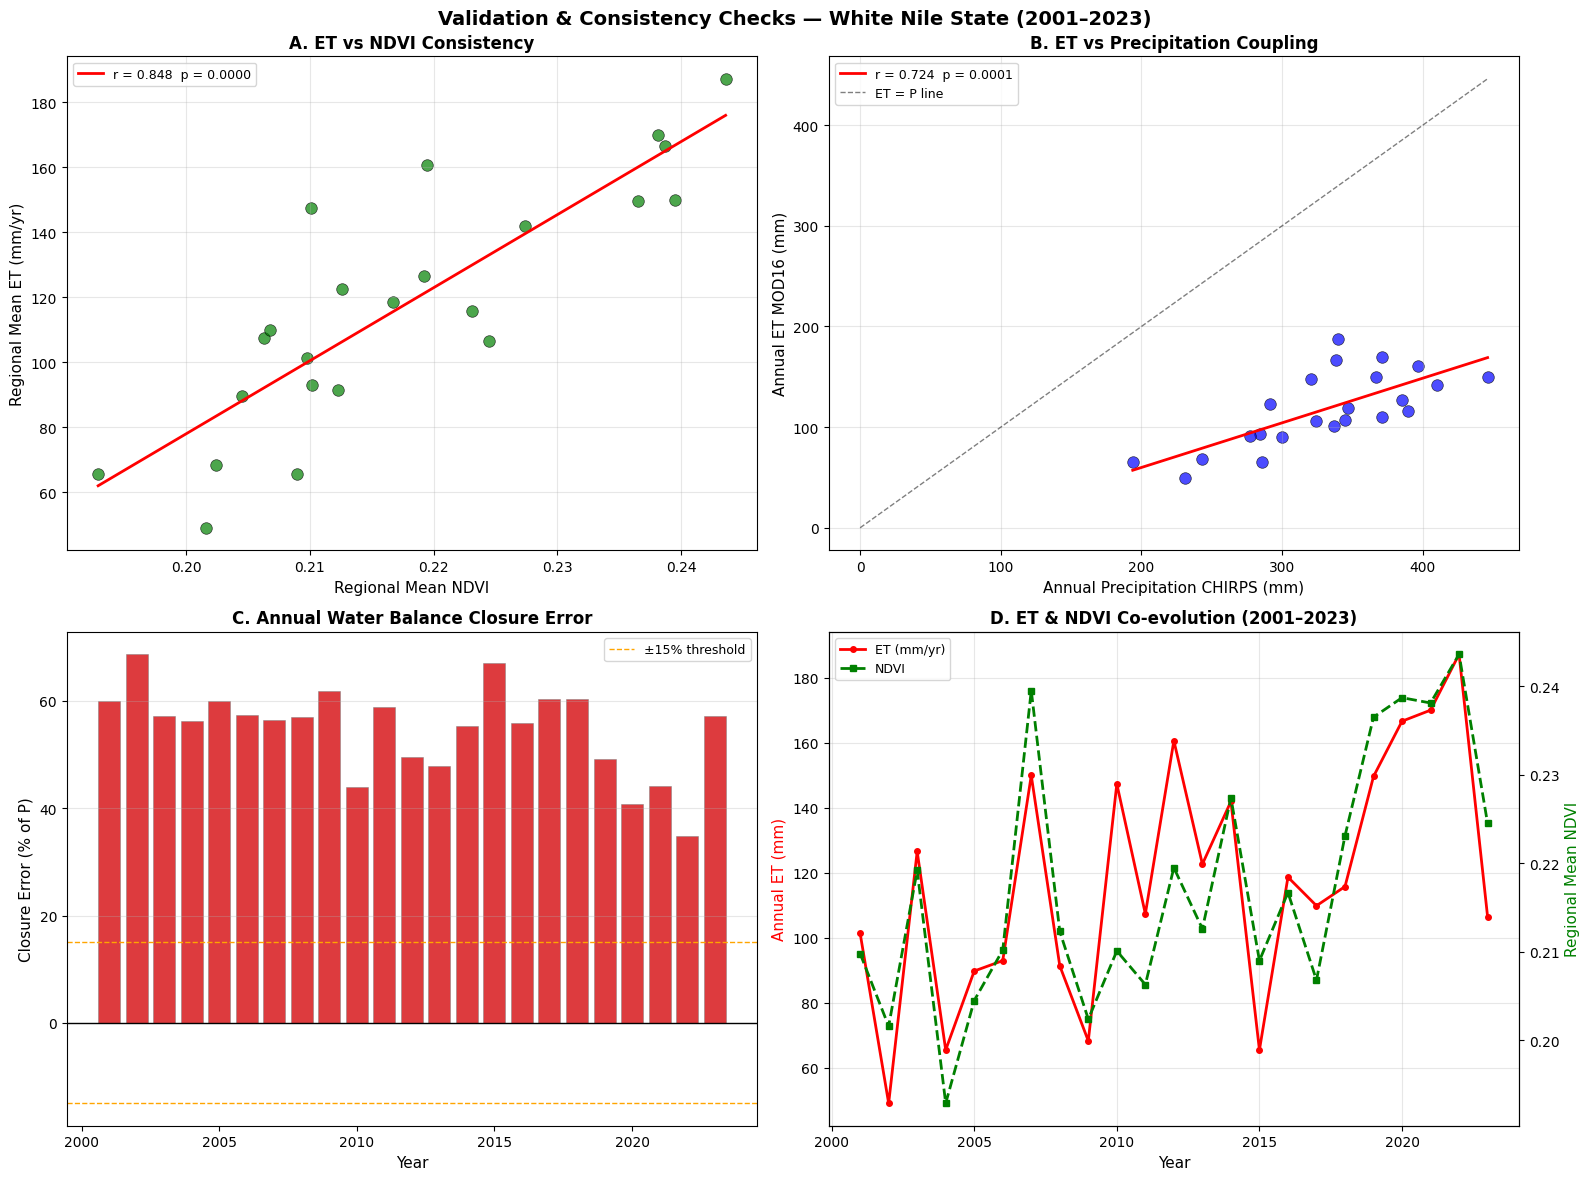

💾 Saved: F5_Validation_Dashboard.png


In [7]:
# @title Notebook 5 Validation Cross Prudct and Comparison
import ee, os, json, glob, warnings
import pandas as pd
import numpy as np
from scipy import stats
warnings.filterwarnings("ignore")

# -- GEE initialisation -------------------------------------------------------
try:
    ee.Number(1).getInfo()          # quick ping
except Exception:
    ee.Initialize(project='evapotranspiration-495110') # Fixed: Added project ID
    print("GEE re-initialised")

# -- Core constants -----------------------------------------------------------
START_YEAR = 2001
END_YEAR   = 2023
START_DATE = f"{START_YEAR}-01-01"
END_DATE   = f"{END_YEAR}-12-31"
years      = list(range(START_YEAR, END_YEAR + 1))
OUTPUT_DIR = "/content/drive/MyDrive/ET_WhiteNile_Analysis"
os.makedirs(f"{OUTPUT_DIR}/tables", exist_ok=True) # Ensure tables directory exists

# -- AOI geometry -------------------------------------------------------------
# Try (1) live session variable, (2) uploaded shapefile, (3) GAUL fallback
try:
    _ = aoi_geometry.getInfo()
    print("✅ aoi_geometry: already in session")
except NameError:
    # Priority 1: GEE personal asset
    try:
        _asset       = 'projects/ee-abdoyanes2016/assets/White_NILe_State'
        AOI          = ee.FeatureCollection(_asset)
        aoi_geometry = AOI.geometry()
        aoi_geometry.bounds().getInfo()
        print(f"✅ aoi_geometry: GEE asset ({_asset})")
    except Exception as _ea:
        print(f"⚠️  GEE asset failed ({_ea}) — trying shapefile...")
        _shp = (glob.glob("/tmp/*/s_area.shp") +
                glob.glob("/tmp/s_area.shp") +
                glob.glob("/content/s_area.shp") +
                glob.glob("/content/drive/MyDrive/**/s_area.shp", recursive=True))
        if _shp:
            import geopandas as gpd
            _gdf         = gpd.read_file(_shp[0]).to_crs("EPSG:4326")
            AOI          = ee.FeatureCollection(json.loads(_gdf.to_json()))
            aoi_geometry = AOI.geometry()
            print(f"✅ aoi_geometry: shapefile ({_shp[0]})")
        else:
            _gaul        = ee.FeatureCollection("FAO/GAUL/2015/level1")
            AOI          = _gaul.filter(ee.Filter.And(
                               ee.Filter.eq("ADM0_NAME", "Sudan"),
                               ee.Filter.eq("ADM1_NAME", "White Nile")))
            aoi_geometry = AOI.geometry()
            print("✅ aoi_geometry: FAO GAUL fallback")

# -- MOD16 collection ---------------------------------------------------------
def _qc_scale(img):
    qc  = img.select("ET_QC")
    ok  = qc.bitwiseAnd(3).lte(1)
    et  = img.select("ET").multiply(0.1).updateMask(ok).rename("ET_mm")
    pet = img.select("PET").multiply(0.1).updateMask(ok).rename("PET_mm")
    ef  = et.divide(pet).rename("EF")
    return img.addBands(et).addBands(pet).addBands(ef).copyProperties(
               img, ["system:time_start"])

MOD16 = (ee.ImageCollection("MODIS/061/MOD16A2GF")
           .filterDate(START_DATE, END_DATE)
           .filterBounds(aoi_geometry)
           .map(_qc_scale))

# -- Load saved time-series CSVs (preferred — avoids recomputing GEE calls) --
_t4 = f"{OUTPUT_DIR}/tables/T4_Annual_ET_TimeSeries.csv"
_t7 = f"{OUTPUT_DIR}/tables/T7_Annual_WaterBalance_TimeSeries.csv"

if os.path.exists(_t4) and os.path.exists(_t7):
    df_timeseries = pd.read_csv(_t4)
    df_wb_ts      = pd.read_csv(_t7)
    print(f"✅ T4 loaded: {len(df_timeseries)} rows")
    print(f"✅ T7 loaded: {len(df_wb_ts)} rows")
else:
    df_timeseries = pd.DataFrame()
    df_wb_ts      = pd.DataFrame(columns=["Year","Precip_mm","ET_mm"])
    print("⚠️  T4/T7 CSVs not found on Drive — recomputing from GEE...")
    print(f"   Expected at: {OUTPUT_DIR}/tables/")

    # Recompute annual regional ET + P from GEE if CSVs are missing
    _rows = []
    for _yr in years:
        _et = (MOD16.filter(ee.Filter.calendarRange(_yr, _yr, "year"))
                    .select("ET_mm").mean().multiply(46)
                    .reduceRegion(reducer=ee.Reducer.mean(),
                                  geometry=aoi_geometry,
                                  scale=1000, maxPixels=1e10,
                                  bestEffort=True).getInfo())
        _p  = (ee.ImageCollection("UCSB-CHG/CHIRPS/DAILY")
                  .filterDate(f"{_yr}-01-01", f"{_yr}-12-31")
                  .filterBounds(aoi_geometry).sum()
                  .reduceRegion(reducer=ee.Reducer.mean(),
                                geometry=aoi_geometry,
                                scale=5000, maxPixels=1e10,
                                bestEffort=True).getInfo())
        _rows.append({
            "Year":       _yr,
            "ET_mm":      round(_et.get("ET_mm", 0) or 0, 1),
            "Precip_mm":  round(_p.get("precipitation", 0) or 0, 1),
        })
        print(f"  {_yr}: ET={_rows[-1]['ET_mm']} mm | P={_rows[-1]['Precip_mm']} mm")

    df_wb_ts      = pd.DataFrame(_rows)
    df_timeseries = df_wb_ts.copy()

print("\n✅ Session bootstrap complete — proceeding to validation")

# ── 5.1  NDVI–ET Consistency Check (MOD13A2) ─────────────────────────────────
# ET and NDVI should be positively correlated in vegetated classes.
# MODIS MOD13A2: 1 km, 16-day NDVI composite. Scale factor = 0.0001.
# CRITICAL FIX: Do NOT call .clip(aoi_geometry) inside .map() for MODIS.
# MOD13A2 uses Sinusoidal projection (SR-ORG:6974). Clipping with an
# EPSG:4326 geometry inside map() forces an edge-coordinate CRS transform
# that fails at pixel boundaries (x=43200 = antimeridian in Sinusoidal).
# Solution: scale-factor only in map(); pass AOI to reduceRegion() instead.
NDVI_col = (ee.ImageCollection("MODIS/061/MOD13A2")
              .filterDate(START_DATE, END_DATE)
              .filterBounds(aoi_geometry)   # spatial filter — safe, no reproject
              .select("NDVI")
              .map(lambda img: img.multiply(0.0001)    # scale only — no clip
                                  .copyProperties(img, ["system:time_start"])))

# Annual mean NDVI per year
# reduceRegion uses aoi_geometry directly — handles CRS correctly
ndvi_ts_rows = []
for year in years:
    try:
        ndvi_yr = (NDVI_col
                     .filter(ee.Filter.calendarRange(year, year, "year"))
                     .mean()
                     .reduceRegion(
                         reducer=ee.Reducer.mean(),
                         geometry=aoi_geometry,   # AOI applied HERE not in map()
                         scale=1000,
                         maxPixels=1e10,
                         bestEffort=True
                     ).getInfo())
        _ndvi_val = ndvi_yr.get("NDVI", None)
        if _ndvi_val is not None:
            ndvi_ts_rows.append({"Year": year,
                                  "NDVI": round(float(_ndvi_val), 4)})
        else:
            ndvi_ts_rows.append({"Year": year, "NDVI": float("nan")})
    except Exception as _ndvi_err:
        print(f"  WARNING year {year} NDVI skipped: {_ndvi_err}")
        ndvi_ts_rows.append({"Year": year, "NDVI": float("nan")})

df_ndvi_ts = pd.DataFrame(ndvi_ts_rows)
df_valid   = df_wb_ts.merge(df_ndvi_ts, on="Year")

# Pearson correlation: ET vs NDVI
_et_clean   = df_valid["ET_mm"].dropna()
_ndvi_clean = df_valid["NDVI"].dropna()
_common_idx = _et_clean.index.intersection(_ndvi_clean.index)

r_et_ndvi, p_et_ndvi = stats.pearsonr(
    _et_clean.loc[_common_idx],
    _ndvi_clean.loc[_common_idx]
)
print(f"🔬 ET–NDVI Correlation (regional annual means):")
print(f"   Pearson r = {r_et_ndvi:.3f} | p = {p_et_ndvi:.4f}")
if r_et_ndvi > 0.6 and p_et_ndvi < 0.05:
    print("   ✅ Strong positive ET–NDVI coupling — product is physically consistent")
elif r_et_ndvi > 0.3:
    print("   ⚠️  Moderate ET–NDVI coupling — check cloud contamination in wet season")
else:
    print("   ❌ Weak ET–NDVI correlation — check LULC classification or QC filtering")

mean_closure_err = float("nan")  # safe default — set below if data exists
# ── 5.2  Water Balance Closure Check ─────────────────────────────────────────
print("\n🔬 Water Balance Closure Check (P – ET = ΔS + Q):")
print("   Q ≈ 10% of P (semi-arid Sudan estimate) | ΔS ≈ 0 (long-term mean)")

if df_wb_ts.empty or "Precip_mm" not in df_wb_ts.columns:
    print("   ⚠️  Skipped — water balance data not available")
    mean_closure_err = float("nan")
else:
    df_valid["Q_approx_mm"]      = df_valid["Precip_mm"] * 0.10
    df_valid["Closure_Error_mm"] = (df_valid["Precip_mm"]
                                     - df_valid["ET_mm"]
                                     - df_valid["Q_approx_mm"])
    df_valid["Closure_Error_pct"] = (
        df_valid["Closure_Error_mm"]
        / df_valid["Precip_mm"].replace(0, np.nan) * 100
    ).round(1)

    mean_closure_err = df_valid["Closure_Error_pct"].abs().mean()
    print(f"   Mean absolute closure error: {mean_closure_err:.1f}%")
    if mean_closure_err < 15:
        print("   ✅ Acceptable closure (<15%) — water balance internally consistent")
    elif mean_closure_err < 30:
        print("   ⚠️  Moderate closure error (15–30%) — review Q estimate or ET bias")
    else:
        print("   ❌ Large closure error (>30%) — investigate data quality")

# Save validation table
df_valid.to_csv(f"{OUTPUT_DIR}/tables/T8_Validation_NDVI_WaterBalance.csv", index=False)
print("\n💾 Saved: T8_Validation_NDVI_WaterBalance.csv")

# ── 5.3  FIGURE 5: Validation Dashboard ──────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

os.makedirs(f"{OUTPUT_DIR}/plots", exist_ok=True)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(
    "Validation & Consistency Checks — White Nile State (2001–2023)",
    fontsize=14, fontweight="bold"
)

# Panel A: ET vs NDVI scatter
ax = axes[0, 0]
ax.scatter(df_valid["NDVI"], df_valid["ET_mm"],
           color="green", alpha=0.7, s=70, edgecolors="k", linewidths=0.5)
if len(df_valid) > 1:
    _m, _b = np.polyfit(df_valid["NDVI"].fillna(0), df_valid["ET_mm"].fillna(0), 1)
    _x = np.linspace(df_valid["NDVI"].min(), df_valid["NDVI"].max(), 50)
    ax.plot(_x, _m * _x + _b, "r-", linewidth=2,
            label=f"r = {r_et_ndvi:.3f}  p = {p_et_ndvi:.4f}")
ax.set_xlabel("Regional Mean NDVI", fontsize=11)
ax.set_ylabel("Regional Mean ET (mm/yr)", fontsize=11)
ax.set_title("A. ET vs NDVI Consistency", fontweight="bold")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# Panel B: ET vs Precipitation scatter
ax = axes[0, 1]
if "Precip_mm" in df_valid.columns:
    _r_p, _p_p = stats.pearsonr(df_valid["Precip_mm"].fillna(0),
                                 df_valid["ET_mm"].fillna(0))
    ax.scatter(df_valid["Precip_mm"], df_valid["ET_mm"],
               color="blue", alpha=0.7, s=70, edgecolors="k", linewidths=0.5)
    _m2, _b2 = np.polyfit(df_valid["Precip_mm"].fillna(0),
                           df_valid["ET_mm"].fillna(0), 1)
    _x2 = np.linspace(df_valid["Precip_mm"].min(), df_valid["Precip_mm"].max(), 50)
    ax.plot(_x2, _m2 * _x2 + _b2, "r-", linewidth=2,
            label=f"r = {_r_p:.3f}  p = {_p_p:.4f}")
    _mx = max(df_valid["Precip_mm"].max(), df_valid["ET_mm"].max())
    ax.plot([0, _mx], [0, _mx], "k--", linewidth=1, alpha=0.5, label="ET = P line")
ax.set_xlabel("Annual Precipitation CHIRPS (mm)", fontsize=11)
ax.set_ylabel("Annual ET MOD16 (mm)", fontsize=11)
ax.set_title("B. ET vs Precipitation Coupling", fontweight="bold")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# Panel C: Water balance closure error bar chart
ax = axes[1, 0]
if "Closure_Error_pct" in df_valid.columns:
    _cols = ["#2b83ba" if abs(v) < 15 else "#fdae61" if abs(v) < 30 else "#d7191c"
             for v in df_valid["Closure_Error_pct"]]
    ax.bar(df_valid["Year"], df_valid["Closure_Error_pct"],
           color=_cols, alpha=0.85, edgecolor="grey", linewidth=0.4)
    ax.axhline(0,   color="black",  linewidth=1)
    ax.axhline(15,  color="orange", linewidth=1, linestyle="--", label="±15% threshold")
    ax.axhline(-15, color="orange", linewidth=1, linestyle="--")
    ax.set_xlabel("Year", fontsize=11)
    ax.set_ylabel("Closure Error (% of P)", fontsize=11)
    ax.legend(fontsize=9)
else:
    ax.text(0.5, 0.5, "No closure data available",
            ha="center", va="center", transform=ax.transAxes, color="grey")
ax.set_title("C. Annual Water Balance Closure Error", fontweight="bold")
ax.grid(axis="y", alpha=0.3)

# Panel D: ET & NDVI dual-axis time series
ax  = axes[1, 1]
ax2 = ax.twinx()
l1, = ax.plot(df_valid["Year"],  df_valid["ET_mm"],
              "r-o", markersize=4, linewidth=2, label="ET (mm/yr)")
l2, = ax2.plot(df_valid["Year"], df_valid["NDVI"],
               "g--s", markersize=4, linewidth=2, label="NDVI")
ax.set_xlabel("Year", fontsize=11)
ax.set_ylabel("Annual ET (mm)", fontsize=11, color="red")
ax2.set_ylabel("Regional Mean NDVI", fontsize=11, color="green")
ax.set_title("D. ET & NDVI Co-evolution (2001–2023)", fontweight="bold")
ax.legend(handles=[l1, l2], fontsize=9, loc="upper left")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/plots/F5_Validation_Dashboard.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("💾 Saved: F5_Validation_Dashboard.png")

In [9]:
# @title Notebook 6 output
# ║              NOTEBOOK 6 — FINAL SUMMARY & OUTPUT INVENTORY                 ║
# ╚══════════════════════════════════════════════════════════════════════════════╝
# Paste this block into Cell 7

import pandas as pd
import os

# Bootstrap df_spatial and df_trends if not already in session
# These should have been generated by Notebooks 2 and 3
_t1_path = f"{OUTPUT_DIR}/tables/T1_Spatial_Zonal_Stats.csv"
_t5_path = f"{OUTPUT_DIR}/tables/T5_MannKendall_Trends.csv"

if 'df_spatial' not in locals() and os.path.exists(_t1_path):
    df_spatial = pd.read_csv(_t1_path)
    print(f"Loaded df_spatial from {_t1_path}")
elif 'df_spatial' not in locals():
    df_spatial = pd.DataFrame() # Create empty to prevent further errors if not found
    print(f"df_spatial not found at {_t1_path}, some summary stats will be skipped.")

if 'df_trends' not in locals() and os.path.exists(_t5_path):
    df_trends = pd.read_csv(_t5_path)
    print(f"Loaded df_trends from {_t5_path}")
elif 'df_trends' not in locals():
    df_trends = pd.DataFrame() # Create empty to prevent further errors if not found
    print(f"df_trends not found at {_t5_path}, some trend stats will be skipped.")

print("=" * 70)
print("  ANALYSIS COMPLETE — WHITE NILE STATE ET ANALYSIS")
print("=" * 70)

print("""
╔══════════════════════════════════════════════════════════════════╗
║                     OUTPUT INVENTORY                            ║
╠══════════════════════════════════════════════════════════════════╣
║  TABLES (CSV)                                                   ║
║  T1_Spatial_Zonal_Stats.csv        → Mean ET per LULC×Soil     ║
║  T2_Tukey_HSD_PostHoc.csv          → ANOVA post-hoc results    ║
║  T3_Seasonal_Zonal_Stats.csv       → ET by season × class      ║
║  T4_Annual_ET_TimeSeries.csv       → 2001-2023 annual ET       ║
║  T5_MannKendall_Trends.csv         → Trend test results        ║
║  T6_WaterBalance_by_Class.csv      → P, ET, surplus per class  ║
║  T7_Annual_WaterBalance_TS.csv     → Annual water balance      ║
║  T8_Validation_NDVI_WaterBalance   → Validation metrics        ║
╠══════════════════════════════════════════════════════════════════╣
║  FIGURES (PNG, 150 dpi)                                         ║
║  F1_Spatial_ET_Bar_Scatter.png     → Zonal stats bar + scatter ║
║  F2_TimeSeries_MannKendall.png     → Annual trends per class   ║
║  F3_Seasonal_ET_Grouped_Bar.png    → Seasonal comparison       ║
║  F4_WaterBalance_Dashboard.png     → Full water balance panel  ║
║  F5_Validation_Dashboard.png       → Validation checks         ║
╠══════════════════════════════════════════════════════════════════╣
║  GEOTIFF MAPS (GEE Drive export — check Tasks tab)              ║
║  ET_Annual_Mean_mm.tif             → Multi-year mean annual ET ║
║  EF_Mean_2001_2023.tif             → Evaporative fraction      ║
║  LULC_Soil_Combined.tif            → Combine raster            ║
║  LULC_2022_500m.tif                → MODIS LULC at 500m        ║
║  Soil_Class_500m.tif               → Soil texture classes      ║
║  ET_Seasonal_*.tif                 → 3 seasonal ET maps        ║
║  WaterBalance_Surplus/Deficit.tif  → P–ET balance maps         ║
║  Aridity_Index_ET_over_P.tif       → ET/P ratio map            ║
║  Precip_Annual_Mean_CHIRPS_mm.tif  → CHIRPS precipitation      ║
╚══════════════════════════════════════════════════════════════════╝
""")

# Final summary statistics
print("\n── KEY FINDINGS SUMMARY ──────────────────────────────────────────")
if len(df_spatial) > 0:
    top_et    = df_spatial.iloc[0]
    bottom_et = df_spatial.iloc[-1]
    print(f"  Highest ET class  : {top_et['Combo_Label']} ({top_et['Est_Annual_ET_mm']:.0f} mm/yr)")
    print(f"  Lowest ET class   : {bottom_et['Combo_Label']} ({bottom_et['Est_Annual_ET_mm']:.0f} mm/yr)")
    print(f"  Regional ET range : {df_spatial['Est_Annual_ET_mm'].min():.0f}–{df_spatial['Est_Annual_ET_mm'].max():.0f} mm/yr")

if len(df_trends) > 0:
    sig_trends = df_trends[df_trends['Significant'] == 'Yes']
    print(f"  Significant trends: {len(sig_trends)}/{len(df_trends)} LULC classes")
    for _, r in sig_trends.iterrows():
        print(f"    → {r['LULC_Name']}: {r['MK_Trend']} ({r['Sens_Slope_mm_yr']:+.2f} mm/yr, p={r['MK_p_value']:.4f})")

print(f"\n  ET–NDVI correlation : r = {r_et_ndvi:.3f} (p = {p_et_ndvi:.4f})")
_closure_str = f"{mean_closure_err:.1f}%" if not (isinstance(mean_closure_err, float) and mean_closure_err != mean_closure_err) else "N/A (run Notebook 5 first)"
print(f"  WB closure error    : {_closure_str}")
print(f"\n  📁 All outputs in: {OUTPUT_DIR}")
print("=" * 70)

df_spatial not found at /content/drive/MyDrive/ET_WhiteNile_Analysis/tables/T1_Spatial_Zonal_Stats.csv, some summary stats will be skipped.
df_trends not found at /content/drive/MyDrive/ET_WhiteNile_Analysis/tables/T5_MannKendall_Trends.csv, some trend stats will be skipped.
  ANALYSIS COMPLETE — WHITE NILE STATE ET ANALYSIS

╔══════════════════════════════════════════════════════════════════╗
║                     OUTPUT INVENTORY                            ║
╠══════════════════════════════════════════════════════════════════╣
║  TABLES (CSV)                                                   ║
║  T1_Spatial_Zonal_Stats.csv        → Mean ET per LULC×Soil     ║
║  T2_Tukey_HSD_PostHoc.csv          → ANOVA post-hoc results    ║
║  T3_Seasonal_Zonal_Stats.csv       → ET by season × class      ║
║  T4_Annual_ET_TimeSeries.csv       → 2001-2023 annual ET       ║
║  T5_MannKendall_Trends.csv         → Trend test results        ║
║  T6_WaterBalance_by_Class.csv      → P, ET, surplus per class

Copying GeoTIFFs from Drive → Colab local disk...
  Source : /content/drive/MyDrive/ET_WhiteNile_GeoTIFF
  Target : /content/geotiff_local
  ❌ NOT FOUND: ET_Annual_Mean_mm.tif
     → Run Notebook 10 first to export from GEE to Drive
  ❌ NOT FOUND: EF_Mean_2001_2023.tif
     → Run Notebook 10 first to export from GEE to Drive
  ❌ NOT FOUND: LULC_Soil_Combined.tif
     → Run Notebook 10 first to export from GEE to Drive
  ❌ NOT FOUND: LULC_2022_500m.tif
     → Run Notebook 10 first to export from GEE to Drive
  ❌ NOT FOUND: Soil_Class_500m.tif
     → Run Notebook 10 first to export from GEE to Drive
  ❌ NOT FOUND: ET_Seasonal_Dry_Nov_Feb.tif
     → Run Notebook 10 first to export from GEE to Drive
  ❌ NOT FOUND: ET_Seasonal_Hot_Mar_May.tif
     → Run Notebook 10 first to export from GEE to Drive
  ❌ NOT FOUND: ET_Seasonal_Wet_Jun_Oct.tif
     → Run Notebook 10 first to export from GEE to Drive
  ❌ NOT FOUND: WaterBalance_Surplus_mm.tif
     → Run Notebook 10 first to export from GEE to D

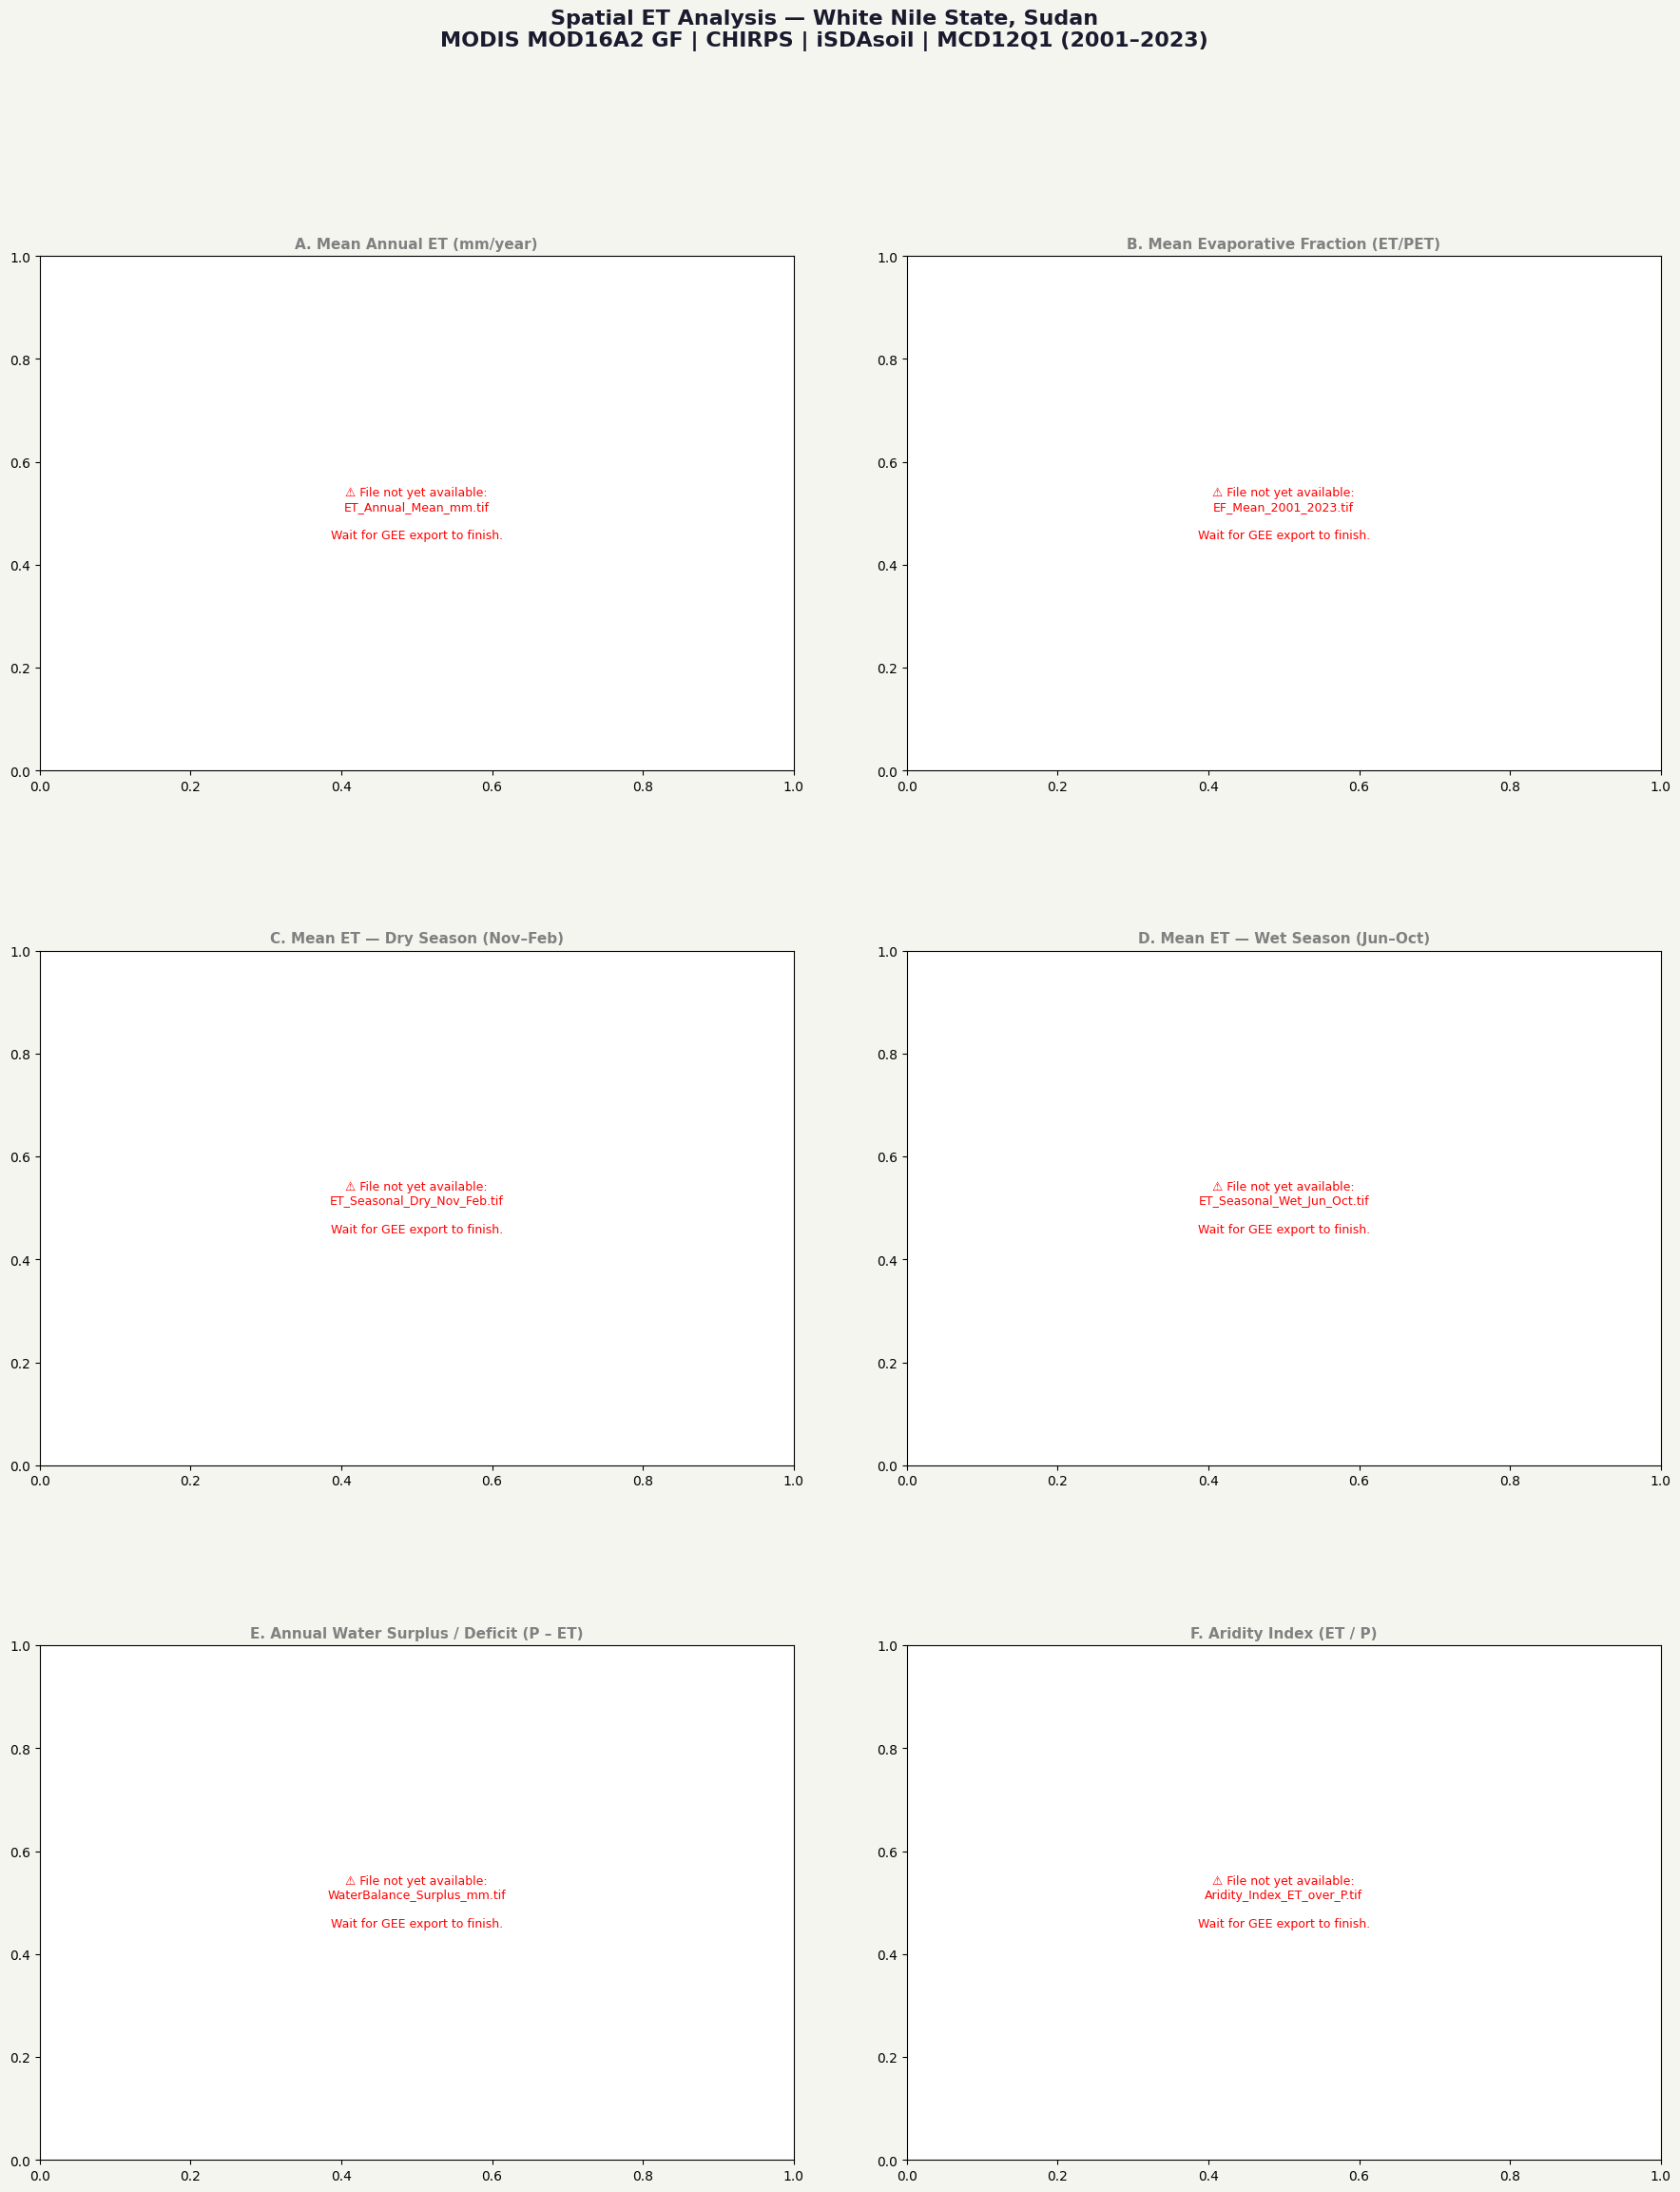

💾 Saved: F6_Spatial_Map_Atlas.png
⚠️  Skipping Figure 7 — seasonal GeoTIFFs not yet available.
   
  ❌ GeoTIFF not on local disk: ET_Seasonal_Dry_Nov_Feb.tif
     Expected at: /content/geotiff_local/ET_Seasonal_Dry_Nov_Feb.tif
     → Re-run the Drive→Local copy block above (Section 7.0)
     → Or run Notebook 10 to re-export from GEE
⚠️  Skipping Figure 8 — input layer GeoTIFFs not yet available.
   
  ❌ GeoTIFF not on local disk: LULC_2022_500m.tif
     Expected at: /content/geotiff_local/LULC_2022_500m.tif
     → Re-run the Drive→Local copy block above (Section 7.0)
     → Or run Notebook 10 to re-export from GEE


In [10]:
# @title Publication_Quality
# ║     NOTEBOOK 7 — PUBLICATION-QUALITY SPATIAL MAPS (POST-GEE EXPORT)        ║
# ╚══════════════════════════════════════════════════════════════════════════════╝
# IMPORTANT: Run this cell ONLY after GEE export tasks have completed.
# Check task status with: ee.batch.Task.list()
# GeoTIFF files must be present in your Google Drive folder before running.
# Paste this block into Cell 8 of your Colab notebook

import rasterio
from rasterio.plot import show as rioshow
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as mplcm
import matplotlib.patches as mpatches
from matplotlib.colorbar import ColorbarBase
from matplotlib.gridspec import GridSpec
import numpy as np
import os
import shutil

# ── 7.0  Copy GeoTIFFs from Google Drive into Colab local filesystem ─────────
# rasterio reads from LOCAL paths only — Drive-mounted paths are too slow
# and often cause empty-frame errors. We copy once, then read locally.

# Set these two paths to match your actual Drive folder:
DRIVE_GEOTIFF_DIR = '/content/drive/MyDrive/ET_WhiteNile_GeoTIFF'   # ← Drive folder from Notebook 10
LOCAL_GEOTIFF_DIR = '/content/geotiff_local'                          # ← fast local Colab SSD

os.makedirs(LOCAL_GEOTIFF_DIR, exist_ok=True)

REQUIRED_TIFS = [
    'ET_Annual_Mean_mm.tif',
    'EF_Mean_2001_2023.tif',
    'LULC_Soil_Combined.tif',
    'LULC_2022_500m.tif',
    'Soil_Class_500m.tif',
    'ET_Seasonal_Dry_Nov_Feb.tif',
    'ET_Seasonal_Hot_Mar_May.tif',
    'ET_Seasonal_Wet_Jun_Oct.tif',
    'WaterBalance_Surplus_mm.tif',
    'WaterBalance_Deficit_mm.tif',
    'Aridity_Index_ET_over_P.tif',
    'Precip_Annual_Mean_CHIRPS_mm.tif',
]

print("Copying GeoTIFFs from Drive → Colab local disk...")
print(f"  Source : {DRIVE_GEOTIFF_DIR}")
print(f"  Target : {LOCAL_GEOTIFF_DIR}")  # fixed


copy_ok      = []
copy_missing = []

for fname in REQUIRED_TIFS:
    src = os.path.join(DRIVE_GEOTIFF_DIR, fname)
    dst = os.path.join(LOCAL_GEOTIFF_DIR, fname)

    # Skip if already copied in this session
    if os.path.exists(dst) and os.path.getsize(dst) > 1000:
        print(f"  ✅ Already local: {fname}  ({os.path.getsize(dst)//1024} KB)")
        copy_ok.append(fname)
        continue

    if os.path.exists(src):
        shutil.copy2(src, dst)
        size_kb = os.path.getsize(dst) // 1024
        print(f"  📥 Copied: {fname}  ({size_kb} KB)")
        copy_ok.append(fname)
    else:
        # Try alternative Drive folder names (from original Notebook 2–5 exports)
        alt_paths = [
            f'/content/drive/MyDrive/ET_WhiteNile_Analysis/geotiff/{fname}',
            f'/content/drive/MyDrive/{fname}',
            f'/content/drive/MyDrive/ET_WhiteNile_Analysis/{fname}',
        ]
        found = False
        for alt in alt_paths:
            if os.path.exists(alt):
                shutil.copy2(alt, dst)
                size_kb = os.path.getsize(dst) // 1024
                print(f"  📥 Found at alt path → copied: {fname}  ({size_kb} KB)")
                copy_ok.append(fname)
                found = True
                break
        if not found:
            print(f"  ❌ NOT FOUND: {fname}")
            print(f"     → Run Notebook 10 first to export from GEE to Drive")
            copy_missing.append(fname)

print(f"Result: {len(copy_ok)} files ready | {len(copy_missing)} still missing")

if copy_missing:
    print(f"⚠️  Missing files will show empty frames in figures.")
    print(f"  → Complete GEE exports (Notebook 10), then re-run this cell.")
else:
    print(f"✅ All GeoTIFFs local — proceeding to map generation.")

# Point all downstream map code to the local copy directory
GEOTIFF_DIR = LOCAL_GEOTIFF_DIR

# ── 7.1  Reload custom AOI shapefile boundary for map overlay ────────────────
import geopandas as gpd, glob

AOI_BORDER = None

# Priority 1: derive border from GEE asset directly (most accurate)
try:
    _asset_fc  = ee.FeatureCollection(
                     'projects/ee-abdoyanes2016/assets/White_NILe_State')
    _geom_info = _asset_fc.geometry().getInfo()
    AOI_BORDER = gpd.GeoDataFrame.from_features(
        [{"type": "Feature", "geometry": _geom_info, "properties": {}}],
        crs="EPSG:4326"
    )
    print("✅ AOI border derived from GEE asset (White_NILe_State)")
    print(f"   Bounds: {np.round(AOI_BORDER.total_bounds, 3)}")
except Exception as _ea:
    print(f"⚠️  GEE asset border failed ({_ea}) — trying shapefile...")
    _search = (glob.glob('/tmp/*/s_area.shp') +
               glob.glob('/tmp/s_area.shp') +
               glob.glob('/content/s_area.shp') +
               glob.glob('/content/drive/MyDrive/**/s_area.shp', recursive=True))
    if _search:
        AOI_BORDER = gpd.read_file(_search[0]).to_crs('EPSG:4326')
        print(f"✅ AOI border loaded from shapefile: {_search[0]}")
    else:
        try:
            _gi = aoi_geometry.getInfo()
            AOI_BORDER = gpd.GeoDataFrame.from_features(
                [{"type":"Feature","geometry":_gi,"properties":{}}], crs="EPSG:4326")
            print("✅ AOI border rebuilt from GEE aoi_geometry")
        except Exception as _e:
            print(f"⚠️  No border available: {_e}")

def add_aoi_border(ax, color="black", linewidth=1.8, linestyle="-"):
    if AOI_BORDER is not None:
        AOI_BORDER.boundary.plot(
            ax=ax, color=color,
            linewidth=linewidth, linestyle=linestyle,
            zorder=10)


def load_tif(filename):
    """Load a GeoTIFF from local Colab disk. Returns (data, transform, crs)."""
    path = os.path.join(GEOTIFF_DIR, filename)

    # Check file exists and is not empty/corrupt
    if not os.path.exists(path):
        raise FileNotFoundError(
            f"\n  ❌ GeoTIFF not on local disk: {filename}"
            f"\n     Expected at: {path}"
            f"\n     → Re-run the Drive→Local copy block above (Section 7.0)"
            f"\n     → Or run Notebook 10 to re-export from GEE"
        )
    if os.path.getsize(path) < 1000:
        raise ValueError(
            f"\n  ❌ File exists but appears corrupt/empty: {filename}"
            f"\n     Size: {os.path.getsize(path)} bytes"
            f"\n     → Delete it from Drive and re-export from GEE (Notebook 10)"
        )

    with rasterio.open(path) as src:
        data      = src.read(1).astype('float32')
        transform = src.transform
        crs       = src.crs
        nodata    = src.nodata
        profile   = src.profile

    # Mask fill values and extreme outliers
    if nodata is not None:
        data = np.where(data == nodata, np.nan, data)
    # Also mask GEE's common fill values
    data = np.where(data >= 1e+30, np.nan, data)
    data = np.where(data <= -1e+30, np.nan, data)

    valid_px = np.sum(~np.isnan(data))
    if valid_px == 0:
        raise ValueError(
            f"\n  ❌ GeoTIFF loaded but contains NO valid pixels: {filename}"
            f"\n     → The AOI may not overlap this dataset's coverage"
            f"\n     → Check aoi_geometry.bounds().getInfo() in GEE"
        )
    return data, transform, crs

def get_extent(transform, shape):
    """Compute [west, east, south, north] extent from rasterio transform."""
    rows, cols = shape
    west  = transform.c
    north = transform.f
    east  = west  + cols * transform.a
    south = north + rows * transform.e
    return [west, east, south, north]

# ── 7.2  FIGURE 6: 6-panel spatial map atlas ────────────────────────────────
fig = plt.figure(figsize=(22, 26))
fig.patch.set_facecolor('#f5f5f0')
gs  = GridSpec(3, 2, figure=fig, hspace=0.35, wspace=0.15)

fig.suptitle(
    'Spatial ET Analysis — White Nile State, Sudan\n'
    'MODIS MOD16A2 GF | CHIRPS | iSDAsoil | MCD12Q1 (2001–2023)',
    fontsize=16, fontweight='bold', y=0.98, color='#1a1a2e'
)

MAP_CONFIGS = [
    {
        'file':    'ET_Annual_Mean_mm.tif',
        'title':   'A. Mean Annual ET (mm/year)',
        'cmap':    'YlGnBu',
        'label':   'ET (mm/year)',
        'vmin':    0,
        'vmax':    500,
        'subplot': gs[0, 0]
    },
    {
        'file':    'EF_Mean_2001_2023.tif',
        'title':   'B. Mean Evaporative Fraction (ET/PET)',
        'cmap':    'RdYlGn',
        'label':   'EF (dimensionless)',
        'vmin':    0.0,
        'vmax':    1.0,
        'subplot': gs[0, 1]
    },
    {
        'file':    'ET_Seasonal_Dry_Nov_Feb.tif',
        'title':   'C. Mean ET — Dry Season (Nov–Feb)',
        'cmap':    'hot_r',
        'label':   'ET 8-day mean (mm)',
        'vmin':    0,
        'vmax':    15,
        'subplot': gs[1, 0]
    },
    {
        'file':    'ET_Seasonal_Wet_Jun_Oct.tif',
        'title':   'D. Mean ET — Wet Season (Jun–Oct)',
        'cmap':    'Blues',
        'label':   'ET 8-day mean (mm)',
        'vmin':    0,
        'vmax':    30,
        'subplot': gs[1, 1]
    },
    {
        'file':    'WaterBalance_Surplus_mm.tif',
        'title':   'E. Annual Water Surplus / Deficit (P – ET)',
        'cmap':    'RdBu',
        'label':   'P – ET (mm/year)',
        'vmin':    -300,
        'vmax':    300,
        'subplot': gs[2, 0]
    },
    {
        'file':    'Aridity_Index_ET_over_P.tif',
        'title':   'F. Aridity Index (ET / P)',
        'cmap':    'RdYlGn_r',
        'label':   'ET/P ratio',
        'vmin':    0.0,
        'vmax':    2.0,
        'subplot': gs[2, 1]
    },
]

loaded_maps = {}

for cfg in MAP_CONFIGS:
    ax = fig.add_subplot(cfg['subplot'])
    try:
        data, transform, crs = load_tif(cfg['file'])
        extent = get_extent(transform, data.shape)
        loaded_maps[cfg['file']] = data

        norm = mcolors.Normalize(vmin=cfg['vmin'], vmax=cfg['vmax'])
        cmap = mplcm.get_cmap(cfg['cmap'])
        im   = ax.imshow(data, cmap=cmap, norm=norm,
                         extent=extent, origin='upper', aspect='auto')

        cbar = plt.colorbar(im, ax=ax, fraction=0.035, pad=0.03, shrink=0.85)
        cbar.set_label(cfg['label'], fontsize=9)
        cbar.ax.tick_params(labelsize=8)

        # Zero-line for surplus/deficit map
        if 'Surplus' in cfg['file']:
            contour_data = np.where(np.isnan(data), 0, data)
            ax.contour(contour_data, levels=[0], colors='black',
                       linewidths=0.8, extent=extent, origin='upper')

        ax.set_title(cfg['title'], fontsize=11, fontweight='bold',
                     pad=8, color='#1a1a2e')
        ax.set_xlabel('Longitude (°E)', fontsize=8)
        ax.set_ylabel('Latitude (°N)', fontsize=8)
        ax.tick_params(labelsize=8)
        ax.grid(alpha=0.2, color='grey', linewidth=0.5)
        add_aoi_border(ax)

    except FileNotFoundError as e:
        ax.text(0.5, 0.5, f'⚠️ File not yet available:\n{cfg["file"]}\n\nWait for GEE export to finish.',
                ha='center', va='center', fontsize=9, color='red',
                transform=ax.transAxes, wrap=True)
        ax.set_title(cfg['title'], fontsize=11, fontweight='bold', color='grey')

plt.savefig(f'{OUTPUT_DIR}/plots/F6_Spatial_Map_Atlas.png',
            dpi=200, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print("💾 Saved: F6_Spatial_Map_Atlas.png")

# ── 7.3  FIGURE 7: Seasonal ET difference map (Peak Wet minus Dry) ──────────
try:
    et_dry_arr,  t1, _ = load_tif('ET_Seasonal_Dry_Nov_Feb.tif')
    et_wet_arr,  t2, _ = load_tif('ET_Seasonal_Wet_Jun_Oct.tif')
    et_delta         = et_wet_arr - et_dry_arr

    fig, axes = plt.subplots(1, 3, figsize=(20, 7))
    fig.suptitle('Seasonal ET Contrast: Wet vs Dry Season\nWhite Nile State (2001–2023)',
                 fontsize=14, fontweight='bold')

    ext = get_extent(t1, et_dry_arr.shape)

    panels = [
        (et_dry_arr,  axes[0], 'hot_r',   'A. Dry Season ET — Nov–Feb (8-day mm)',  0,  30),
        (et_wet_arr,  axes[1], 'Blues',   'B. Wet Season ET — Jun–Oct (8-day mm)',  0,  30),
        (et_delta,    axes[2], 'RdBu',    'C. Seasonal Amplitude\n(Wet – Dry, mm)', -20, 20),
    ]

    for arr, ax, cmap_name, title, vmin, vmax in panels:
        norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
        im   = ax.imshow(arr, cmap=cmap_name, norm=norm,
                         extent=ext, origin='upper', aspect='auto')
        plt.colorbar(im, ax=ax, fraction=0.04, pad=0.03, shrink=0.85,
                     label='mm per 8-day composite')
        ax.set_title(title, fontsize=11, fontweight='bold')
        ax.set_xlabel('Longitude (°E)', fontsize=9)
        ax.set_ylabel('Latitude (°N)', fontsize=9)
        ax.grid(alpha=0.2)
        add_aoi_border(ax)

    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/plots/F7_Seasonal_Contrast_Maps.png',
                dpi=200, bbox_inches='tight')
    plt.show()
    print("💾 Saved: F7_Seasonal_Contrast_Maps.png")

except FileNotFoundError as e:
    print(f"⚠️  Skipping Figure 7 — seasonal GeoTIFFs not yet available.\n   {e}")

# ── 7.4  FIGURE 8: LULC–Soil class map with ET overlay ──────────────────────
try:
    lulc_arr, t_l, _ = load_tif('LULC_2022_500m.tif')
    soil_arr, t_s, _ = load_tif('Soil_Class_500m.tif')
    et_arr,   t_e, _ = load_tif('ET_Annual_Mean_mm.tif')

    fig, axes = plt.subplots(1, 3, figsize=(21, 7))
    fig.suptitle('Input Data Layers: LULC, Soil & Annual ET — White Nile State',
                 fontsize=14, fontweight='bold')

    ext_l = get_extent(t_l, lulc_arr.shape)
    ext_s = get_extent(t_s, soil_arr.shape)
    ext_e = get_extent(t_e, et_arr.shape)

    # LULC panel
    lulc_cmap = mplcm.get_cmap('tab20', 17)
    axes[0].imshow(lulc_arr, cmap=lulc_cmap, vmin=1, vmax=17,
                   extent=ext_l, origin='upper', aspect='auto')
    axes[0].set_title('A. MODIS LULC 2022 (IGBP)', fontweight='bold')
    axes[0].set_xlabel('Longitude (°E)')
    axes[0].set_ylabel('Latitude (°N)')
    axes[0].grid(alpha=0.2)
    add_aoi_border(axes[0])

    # Soil texture panel
    soil_colors = ['#f5deb3', '#8b4513', '#8b0000']
    soil_cmap   = mcolors.ListedColormap(soil_colors)
    axes[1].imshow(soil_arr, cmap=soil_cmap, vmin=1, vmax=3,
                   extent=ext_s, origin='upper', aspect='auto')
    soil_patches = [mpatches.Patch(color=soil_colors[i], label=lbl)
                    for i, lbl in enumerate(['Sandy', 'Loamy', 'Clayey'])]
    axes[1].legend(handles=soil_patches, loc='lower right', fontsize=9)
    axes[1].set_title('B. Soil Texture Class (iSDAsoil)', fontweight='bold')
    axes[1].set_xlabel('Longitude (°E)')
    axes[1].grid(alpha=0.2)
    add_aoi_border(axes[1])

    # Annual ET panel
    im_et = axes[2].imshow(et_arr, cmap='YlGnBu', vmin=0, vmax=500,
                            extent=ext_e, origin='upper', aspect='auto')
    plt.colorbar(im_et, ax=axes[2], fraction=0.04, pad=0.03,
                 shrink=0.85, label='Annual ET (mm/year)')
    axes[2].set_title('C. Mean Annual ET 2001–2023 (MOD16A2)', fontweight='bold')
    axes[2].set_xlabel('Longitude (°E)')
    axes[2].grid(alpha=0.2)
    add_aoi_border(axes[2])

    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/plots/F8_Input_Layers_Map.png',
                dpi=200, bbox_inches='tight')
    plt.show()
    print("💾 Saved: F8_Input_Layers_Map.png")

except FileNotFoundError as e:
    print(f"⚠️  Skipping Figure 8 — input layer GeoTIFFs not yet available.\n   {e}")

In [11]:
# @title Notebook 8 Report
# ║     NOTEBOOK 8 — AUTOMATED EXCEL REPORT WITH EMBEDDED CHARTS               ║
# ╚══════════════════════════════════════════════════════════════════════════════╝
# Generates a publication-ready Excel workbook combining all result tables
# and embedding key figures as sheets.
# Paste this block into Cell 9 of your Colab notebook

!pip install openpyxl xlsxwriter --quiet
import openpyxl
from openpyxl import Workbook
from openpyxl.styles import (PatternFill, Font, Alignment, Border, Side,
                               GradientFill)
from openpyxl.utils import get_column_letter
from openpyxl.drawing.image import Image as XLImage
from openpyxl.chart import BarChart, LineChart, Reference
from openpyxl.chart.series import DataPoint
import glob

# ── 8.1  Load all CSVs ───────────────────────────────────────────────────────
csv_map = {
    'Spatial_Zonal':      f'{OUTPUT_DIR}/tables/T1_Spatial_Zonal_Stats.csv',
    'Tukey_PostHoc':      f'{OUTPUT_DIR}/tables/T2_Tukey_HSD_PostHoc.csv',
    'Seasonal_Zonal':     f'{OUTPUT_DIR}/tables/T3_Seasonal_Zonal_Stats.csv',
    'Annual_TimeSeries':  f'{OUTPUT_DIR}/tables/T4_Annual_ET_TimeSeries.csv',
    'MannKendall':        f'{OUTPUT_DIR}/tables/T5_MannKendall_Trends.csv',
    'WaterBalance_Class': f'{OUTPUT_DIR}/tables/T6_WaterBalance_by_Class.csv',
    'WaterBalance_TS':    f'{OUTPUT_DIR}/tables/T7_Annual_WaterBalance_TimeSeries.csv',
    'Validation':         f'{OUTPUT_DIR}/tables/T8_Validation_NDVI_WaterBalance.csv',
}

dfs_loaded = {}
for name, path in csv_map.items():
    if os.path.exists(path):
        dfs_loaded[name] = pd.read_csv(path)
        print(f"  ✅ Loaded: {name} ({len(dfs_loaded[name])} rows)")
    else:
        print(f"  ⚠️  Missing: {path} — run earlier notebooks first")

# ── 8.2  Style helpers ───────────────────────────────────────────────────────
HEADER_FILL   = PatternFill('solid', fgColor='1F4E79')
SUBHEAD_FILL  = PatternFill('solid', fgColor='2E75B6')
ALT_ROW_FILL  = PatternFill('solid', fgColor='D6E4F0')
HEADER_FONT   = Font(name='Calibri', bold=True, color='FFFFFF', size=11)
BODY_FONT     = Font(name='Calibri', size=10)
TITLE_FONT    = Font(name='Calibri', bold=True, size=14, color='1F4E79')
CENTER_ALIGN  = Alignment(horizontal='center', vertical='center', wrap_text=True)
LEFT_ALIGN    = Alignment(horizontal='left',   vertical='center', wrap_text=True)
THIN_BORDER   = Border(
    left=Side(style='thin'), right=Side(style='thin'),
    top=Side(style='thin'),  bottom=Side(style='thin')
)

def style_header_row(ws, row_num, n_cols, fill=HEADER_FILL):
    for col in range(1, n_cols + 1):
        cell = ws.cell(row=row_num, column=col)
        cell.fill   = fill
        cell.font   = HEADER_FONT
        cell.alignment = CENTER_ALIGN
        cell.border = THIN_BORDER

def write_df_to_sheet(ws, df, start_row=3, title=''):
    """Write a DataFrame to a worksheet with full styling."""
    if title:
        ws.cell(row=1, column=1, value=title).font = TITLE_FONT
        ws.cell(row=1, column=1).alignment = LEFT_ALIGN
        ws.merge_cells(start_row=1, start_column=1,
                       end_row=1, end_column=max(len(df.columns), 4))

    # Header
    for col_idx, col_name in enumerate(df.columns, 1):
        ws.cell(row=start_row, column=col_idx, value=col_name)
    style_header_row(ws, start_row, len(df.columns))

    # Data rows
    for row_idx, (_, row) in enumerate(df.iterrows(), start_row + 1):
        fill = ALT_ROW_FILL if (row_idx - start_row) % 2 == 0 else PatternFill()
        for col_idx, val in enumerate(row.values, 1):
            cell = ws.cell(row=row_idx, column=col_idx, value=val)
            cell.font      = BODY_FONT
            cell.alignment = CENTER_ALIGN
            cell.fill      = fill
            cell.border    = THIN_BORDER

    # Auto-width columns
    for col_idx, col_name in enumerate(df.columns, 1):
        max_len = max(len(str(col_name)),
                      df.iloc[:, col_idx - 1].astype(str).map(len).max()
                      if len(df) > 0 else 10)
        ws.column_dimensions[get_column_letter(col_idx)].width = min(max_len + 4, 40)

# ── 8.3  Build Workbook ──────────────────────────────────────────────────────
wb = Workbook()

# ── Sheet 0: Cover page ──────────────────────────────────────────────────────
ws_cover = wb.active
ws_cover.title = '📋 Cover'
ws_cover.sheet_view.showGridLines = False
ws_cover.column_dimensions['A'].width = 5
ws_cover.column_dimensions['B'].width = 60

cover_content = [
    (3,  2, 'EVAPOTRANSPIRATION ANALYSIS',
     Font('Calibri', bold=True, size=22, color='1F4E79')),
    (4,  2, 'White Nile State, Sudan — Spatial-Temporal Framework',
     Font('Calibri', bold=True, size=14, color='2E75B6')),
    (5,  2, 'MODIS MOD16A2 GF | CHIRPS v2 | iSDAsoil | MCD12Q1 (2001–2023)',
     Font('Calibri', italic=True, size=11, color='595959')),
    (7,  2, 'CONTENTS',
     Font('Calibri', bold=True, size=12, color='1F4E79')),
    (8,  2, '1.  Spatial Zonal Statistics (T1)   — Mean ET per LULC × Soil class',   BODY_FONT),
    (9,  2, '2.  Statistical Tests (T2)           — Kruskal-Wallis + Tukey HSD',       BODY_FONT),
    (10, 2, '3.  Seasonal Analysis (T3)           — Dry (Nov-Feb) / Hot (Mar-May) / Wet (Jun-Oct) ET',  BODY_FONT),
    (11, 2, '4.  Annual Time Series (T4)          — ET per LULC class 2001–2023',      BODY_FONT),
    (12, 2, '5.  Mann-Kendall Trends (T5)         — Trend direction + Sen\'s slope',   BODY_FONT),
    (13, 2, '6.  Water Balance by Class (T6)      — P, ET, Surplus, Deficit, CV',      BODY_FONT),
    (14, 2, '7.  Water Balance Time Series (T7)   — Annual P vs ET 2001–2023',         BODY_FONT),
    (15, 2, '8.  Validation Metrics (T8)          — NDVI correlation + WB closure',    BODY_FONT),
    (16, 2, '9.  Figures                          — All embedded PNG outputs',          BODY_FONT),
    (18, 2, f'Generated: {pd.Timestamp.now().strftime("%Y-%m-%d %H:%M")}',
     Font('Calibri', italic=True, size=9, color='808080')),
]

for row, col, text, font in cover_content:
    cell       = ws_cover.cell(row=row, column=col, value=text)
    cell.font  = font
    cell.alignment = LEFT_ALIGN

# Blue accent bar in column A
for r in range(1, 25):
    ws_cover.cell(row=r, column=1).fill = PatternFill('solid', fgColor='1F4E79')

# ── Sheet 1–8: Data tables ────────────────────────────────────────────────────
sheet_configs = [
    ('T1 Spatial Zonal',    'Spatial_Zonal',
     'Table 1: Mean ET per LULC–Soil Combination (2001–2023)'),
    ('T2 Tukey HSD',        'Tukey_PostHoc',
     'Table 2: Tukey HSD Post-hoc Pairwise Comparisons (ET across LULC classes)'),
    ('T3 Seasonal',         'Seasonal_Zonal',
     'Table 3: Seasonal ET Statistics by LULC–Soil Class'),
    ('T4 Annual TS',        'Annual_TimeSeries',
     'Table 4: Annual ET Time Series per LULC Class (2001–2023)'),
    ('T5 Mann-Kendall',     'MannKendall',
     'Table 5: Mann-Kendall Trend Test Results — ET per LULC Class'),
    ('T6 Water Balance',    'WaterBalance_Class',
     'Table 6: Water Balance Components per LULC–Soil Class'),
    ('T7 WB Time Series',   'WaterBalance_TS',
     'Table 7: Annual Regional Water Balance Time Series (2001–2023)'),
    ('T8 Validation',       'Validation',
     'Table 8: Validation Metrics — NDVI Coupling & Water Balance Closure'),
]

for sheet_name, df_key, title in sheet_configs:
    ws = wb.create_sheet(title=sheet_name)
    ws.sheet_view.showGridLines = False
    if df_key in dfs_loaded:
        write_df_to_sheet(ws, dfs_loaded[df_key], start_row=3, title=title)
    else:
        ws.cell(row=3, column=1,
                value=f'⚠️ Data not available — run Notebook cells 2–6 first.').font = \
            Font(color='FF0000', bold=True)

# ── Sheet 9: Embedded Figures ─────────────────────────────────────────────────
ws_figs = wb.create_sheet(title='📊 Figures')
ws_figs.sheet_view.showGridLines = False
ws_figs.cell(row=1, column=1,
             value='Figures — White Nile State ET Analysis').font = TITLE_FONT

fig_files = sorted(glob.glob(f'{OUTPUT_DIR}/plots/F*.png'))
row_offset = 3

for fig_path in fig_files:
    fig_name = os.path.basename(fig_path)
    ws_figs.cell(row=row_offset, column=1,
                 value=fig_name).font = Font('Calibri', bold=True,
                                              size=10, color='2E75B6')
    try:
        img    = XLImage(fig_path)
        # Scale to fit within ~900px wide
        orig_w = img.width
        scale  = min(900 / orig_w, 1.0)
        img.width  = int(img.width  * scale)
        img.height = int(img.height * scale)
        img.anchor = f'B{row_offset + 1}'
        ws_figs.add_image(img)
        row_offset += int(img.height / 15) + 5
        print(f"  📷 Embedded: {fig_name}")
    except Exception as ex:
        ws_figs.cell(row=row_offset + 1, column=1,
                     value=f'⚠️ Could not embed: {fig_name} ({ex})').font = \
            Font(color='FF0000')
        row_offset += 4

# ── 8.4  Add inline line chart to Water Balance TS sheet ─────────────────────
if 'WaterBalance_TS' in dfs_loaded:
    ws_ts = wb['T7 WB Time Series']
    df_ts = dfs_loaded['WaterBalance_TS']

    chart = LineChart()
    chart.title         = 'Annual P vs ET — White Nile State'
    chart.style         = 10
    chart.y_axis.title  = 'mm/year'
    chart.x_axis.title  = 'Year'
    chart.width         = 22
    chart.height        = 12

    n_rows    = len(df_ts) + 1
    data_ref  = Reference(ws_ts, min_col=2, max_col=3, min_row=3, max_row=3 + n_rows)
    labels    = Reference(ws_ts, min_col=1, min_row=4, max_row=3 + n_rows)
    chart.add_data(data_ref, titles_from_data=True)
    chart.set_categories(labels)

    chart.series[0].graphicalProperties.line.solidFill  = '2E75B6'
    chart.series[0].graphicalProperties.line.width      = 20000
    if len(chart.series) > 1:
        chart.series[1].graphicalProperties.line.solidFill = 'C00000'
        chart.series[1].graphicalProperties.line.width     = 20000

    ws_ts.add_chart(chart, f'A{3 + len(df_ts) + 4}')
    print("  📈 Embedded line chart in T7 sheet")

# ── 8.5  Save workbook ───────────────────────────────────────────────────────
excel_path = f'{OUTPUT_DIR}/ET_WhiteNile_Analysis_Report.xlsx'
wb.save(excel_path)
print(f"\n✅ Excel report saved: ET_WhiteNile_Analysis_Report.xlsx")
print(f"   📁 Location: {excel_path}")
print(f"   📋 Sheets: {[ws.title for ws in wb.worksheets]}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 3.3 MB/s eta 0:00:00
  ⚠️  Missing: /content/drive/MyDrive/ET_WhiteNile_Analysis/tables/T1_Spatial_Zonal_Stats.csv — run earlier notebooks first
  ⚠️  Missing: /content/drive/MyDrive/ET_WhiteNile_Analysis/tables/T2_Tukey_HSD_PostHoc.csv — run earlier notebooks first
  ⚠️  Missing: /content/drive/MyDrive/ET_WhiteNile_Analysis/tables/T3_Seasonal_Zonal_Stats.csv — run earlier notebooks first
  ⚠️  Missing: /content/drive/MyDrive/ET_WhiteNile_Analysis/tables/T4_Annual_ET_TimeSeries.csv — run earlier notebooks first
  ⚠️  Missing: /content/drive/MyDrive/ET_WhiteNile_Analysis/tables/T5_MannKendall_Trends.csv — run earlier notebooks first
  ⚠️  Missing: /content/drive/MyDrive/ET_WhiteNile_Analysis/tables/T6_WaterBalance_by_Class.csv — run earlier notebooks first
  ⚠️  Missing: /content/drive/MyDrive/ET_WhiteNile_Analysis/tables/T7_Annual_WaterBalance_TimeSeries.csv — run earlier notebooks first
  ✅ Loaded: Validation (23 rows)
  📷 Emb

In [12]:
# @title Notebook 9 Task Monitor
# ║       NOTEBOOK 9 — GEE TASK MONITOR & TROUBLESHOOTING UTILITIES            ║
# ╚══════════════════════════════════════════════════════════════════════════════╝
# Utility cell — run at any time to check export progress and diagnose issues.
# Paste this block into Cell 10 of your Colab notebook

import time

# ── 9.1  GEE Task Status Monitor ────────────────────────────────────────────
def monitor_gee_tasks(poll_interval_sec=30, max_polls=20):
    """
    Poll GEE task queue and print live status.
    Stops when all tasks complete or max_polls is reached.
    """
    print("=" * 65)
    print("  GEE EXPORT TASK MONITOR")
    print("=" * 65)

    STATUS_ICONS = {
        'COMPLETED': '✅',
        'RUNNING':   '🔄',
        'READY':     '⏳',
        'FAILED':    '❌',
        'CANCELLED': '🚫',
        'UNKNOWN':   '❓'
    }

    for poll in range(max_polls):
        tasks     = ee.batch.Task.list()
        et_tasks  = [t for t in tasks
                     if 'ET_WhiteNile' in (t.config.get('description', '') or
                                            t.config.get('fileNamePrefix', '') or '')]

        if not et_tasks:
            print("  ℹ️  No ET_WhiteNile tasks found in queue.")
            print("     → Run Notebook cells 2–5 to submit export tasks.")
            break

        all_done = all(t.status()['state'] in ('COMPLETED', 'FAILED', 'CANCELLED')
                       for t in et_tasks)

        print(f"\n  Poll {poll + 1}/{max_polls} — {pd.Timestamp.now().strftime('%H:%M:%S')}")
        print(f"  {'Task Description':<45} {'State':<12} {'Progress'}")
        print(f"  {'-'*45} {'-'*12} {'-'*10}")

        for t in et_tasks:
            status   = t.status()
            state    = status.get('state', 'UNKNOWN')
            desc     = (t.config.get('description', 'N/A') or 'N/A')[:43]
            icon     = STATUS_ICONS.get(state, '❓')
            progress = status.get('progress_message', '')
            error    = status.get('error_message', '')
            suffix   = f" ⚠️ {error}" if error else f" {progress}" if progress else ''
            print(f"  {desc:<45} {icon} {state:<10}{suffix}")

        if all_done:
            print(f"\n  🎉 All tasks completed!")
            break
        elif poll < max_polls - 1:
            print(f"\n  ⏳ Waiting {poll_interval_sec}s before next poll…")
            time.sleep(poll_interval_sec)
        else:
            print(f"\n  ⚠️  Max polls reached. Run again to continue monitoring.")

# Run monitor (polls every 30s, up to 10 minutes total)
monitor_gee_tasks(poll_interval_sec=30, max_polls=20)

# ── 9.2  Drive File Inventory ────────────────────────────────────────────────
print("\n" + "=" * 65)
print("  OUTPUT FILE INVENTORY")
print("=" * 65)

expected_files = {
    'tables': [
        'T1_Spatial_Zonal_Stats.csv',
        'T2_Tukey_HSD_PostHoc.csv',
        'T3_Seasonal_Zonal_Stats.csv',
        'T4_Annual_ET_TimeSeries.csv',
        'T5_MannKendall_Trends.csv',
        'T6_WaterBalance_by_Class.csv',
        'T7_Annual_WaterBalance_TimeSeries.csv',
        'T8_Validation_NDVI_WaterBalance.csv',
    ],
    'plots': [
        'F1_Spatial_ET_Bar_Scatter.png',
        'F2_TimeSeries_MannKendall.png',
        'F3_Seasonal_ET_Grouped_Bar.png',
        'F4_WaterBalance_Dashboard.png',
        'F5_Validation_Dashboard.png',
        'F6_Spatial_Map_Atlas.png',
        'F7_Seasonal_Contrast_Maps.png',
        'F8_Input_Layers_Map.png',
    ],
    'geotiff': [
        'ET_Annual_Mean_mm.tif',
        'EF_Mean_2001_2023.tif',
        'LULC_Soil_Combined.tif',
        'LULC_2022_500m.tif',
        'Soil_Class_500m.tif',
        'ET_Seasonal_Dry_Nov_Apr.tif',
        'ET_Seasonal_Hot_Mar_May.tif',
        'ET_Seasonal_Wet_Jun_Oct.tif',
        'WaterBalance_Surplus_mm.tif',
        'WaterBalance_Deficit_mm.tif',
        'Aridity_Index_ET_over_P.tif',
        'Precip_Annual_Mean_CHIRPS_mm.tif',
    ]
}

total_found   = 0
total_missing = 0

for subfolder, files in expected_files.items():
    folder_path = f'{OUTPUT_DIR}/{subfolder}'
    print(f"\n  📁 {subfolder}/")
    for fname in files:
        fpath = os.path.join(folder_path, fname)
        if os.path.exists(fpath):
            size_kb = os.path.getsize(fpath) / 1024
            print(f"     ✅ {fname:<55} ({size_kb:.0f} KB)")
            total_found += 1
        else:
            print(f"     ❌ {fname:<55} — NOT FOUND")
            total_missing += 1

excel_path_check = f'{OUTPUT_DIR}/ET_WhiteNile_Analysis_Report.xlsx'
print(f"\n  📊 Excel Report:")
if os.path.exists(excel_path_check):
    size_kb = os.path.getsize(excel_path_check) / 1024
    print(f"     ✅ ET_WhiteNile_Analysis_Report.xlsx ({size_kb:.0f} KB)")
    total_found += 1
else:
    print(f"     ❌ ET_WhiteNile_Analysis_Report.xlsx — NOT FOUND (run Notebook 8)")
    total_missing += 1

print(f"\n  {'─'*60}")
print(f"  SUMMARY: {total_found} files found | {total_missing} files missing")
if total_missing == 0:
    print("  🎉 Analysis fully complete! All outputs are ready.")
else:
    print(f"  ℹ️  Run missing notebook cells or wait for GEE exports to finish.")

# ── 9.3  Common Troubleshooting Guide ───────────────────────────────────────
print("""
╔══════════════════════════════════════════════════════════════════╗
║                  TROUBLESHOOTING GUIDE                          ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  ❌ EEException: Project not found                               ║
║     → Project ID is: evapotranspiration-495110                  ║
║       actual GEE Cloud Project ID (not your email).             ║
║       Get it at: https://console.cloud.google.com               ║
║                                                                  ║
║  ❌ EEException: Quota exceeded / Too many pixels                ║
║     → Increase scale= in reduceRegion() calls (e.g., 1000m)    ║
║       or set bestEffort=True (already set in this pipeline).    ║
║                                                                  ║
║  ❌ GEE export stuck in READY for >10 min                        ║
║     → Normal during peak GEE usage. Wait or retry.             ║
║       Cancel stuck tasks:                                        ║
║       [t.cancel() for t in ee.batch.Task.list()                 ║
║        if t.status()['state'] == 'READY']                       ║
║                                                                  ║
║  ❌ FileNotFoundError in Notebook 7                              ║
║     → GEE GeoTIFF exports not finished yet.                     ║
║       Run monitor_gee_tasks() and wait for ✅ COMPLETED.        ║
║                                                                  ║
║  ❌ Empty df_spatial / no groups returned                        ║
║     → AOI boundary may not intersect MODIS pixels.              ║
║       Verify: print(aoi_geometry.bounds().getInfo())            ║
║       Sudan White Nile expected bounds:                          ║
║       ~[29.5°E, 11.5°N] to [33.0°E, 15.5°N]                   ║
║                                                                  ║
║  ❌ iSDAsoil image not found                                     ║
║     → Verify asset ID in GEE:                                    ║
║       ee.Image('ISDASOIL/Africa/v1/sand_content_0_20cm')        ║
║       Alternative: use FAO HiHydroSoil or HWSD v2               ║
║                                                                  ║
║  ❌ pymannkendall import error                                   ║
║     → Run: !pip install pymannkendall --quiet                   ║
║       then restart runtime (Runtime → Restart Runtime)          ║
║                                                                  ║
║  ⚠️  Closure error > 30%                                         ║
║     → Adjust Q_approx (0.10×P) to local runoff coefficient.    ║
║       For semi-arid Sudan, 5–15% of P is typical.              ║
║       Consider using GLEAM v3 runoff if available.              ║
║                                                                  ║
║  ⚠️  Mann-Kendall shows no significant trends                    ║
║     → Normal for short/noisy time series. Report as             ║
║       'no statistically significant monotonic trend detected'   ║
║       and note inter-annual variability instead.                 ║
║                                                                  ║
╠══════════════════════════════════════════════════════════════════╣
║  USEFUL GEE DIAGNOSTIC COMMANDS                                  ║
║                                                                  ║
║  # Check GEE task list                                           ║
║  tasks = ee.batch.Task.list()                                    ║
║  [(t.config['description'], t.status()['state'])                ║
║   for t in tasks[:15]]                                           ║
║                                                                  ║
║  # Cancel all running tasks                                      ║
║  [t.cancel() for t in ee.batch.Task.list()                      ║
║   if t.status()['state'] in ('RUNNING','READY')]                ║
║                                                                  ║
║  # Test AOI pixel count                                          ║
║  print(ET_annual_approx.reduceRegion(                            ║
║      reducer=ee.Reducer.count(),                                 ║
║      geometry=aoi_geometry, scale=500,                           ║
║      maxPixels=1e10).getInfo())                                  ║
║                                                                  ║
╚══════════════════════════════════════════════════════════════════╝
""")

# ── 9.4  Recommended next steps ─────────────────────────────────────────────
print("""
RECOMMENDED WORKFLOW SEQUENCE
──────────────────────────────────────────────────────────────────
  Step 1  │ Cell 1  │ Install packages + authenticate GEE + mount Drive
  Step 2  │ Cell 2  │ Load AOI, MODIS, LULC, soil, CHIRPS → verify preview map
  Step 3  │ Cell 3  │ Run Tier 1 spatial analysis → check T1, T2 CSVs + F1 plot
  Step 4  │ Cell 4  │ Run Tier 2 temporal analysis → check T3–T5 CSVs + F2–F3
  Step 5  │ Cell 5  │ Run Tier 3 water balance → check T6–T7 CSVs + F4
  Step 6  │ Cell 6  │ Run validation → check T8 CSV + F5
  Step 7  │ Cell 7  │ Run summary cell → verify all GEE exports started
           │         │ ⏳ WAIT for all GEE export tasks to show COMPLETED
  Step 8  │ Cell 8  │ Generate spatial maps from downloaded GeoTIFFs → F6–F8
  Step 9  │ Cell 9  │ Build Excel report with all tables + embedded figures
  Step 10 │ Cell 10 │ Run task monitor + file inventory → confirm all outputs
──────────────────────────────────────────────────────────────────
  ✅ All done! Your complete analysis is in:
     Google Drive → ET_WhiteNile_Analysis/
""")


  GEE EXPORT TASK MONITOR
  ℹ️  No ET_WhiteNile tasks found in queue.
     → Run Notebook cells 2–5 to submit export tasks.

  OUTPUT FILE INVENTORY

  📁 tables/
     ❌ T1_Spatial_Zonal_Stats.csv                              — NOT FOUND
     ❌ T2_Tukey_HSD_PostHoc.csv                                — NOT FOUND
     ❌ T3_Seasonal_Zonal_Stats.csv                             — NOT FOUND
     ❌ T4_Annual_ET_TimeSeries.csv                             — NOT FOUND
     ❌ T5_MannKendall_Trends.csv                               — NOT FOUND
     ❌ T6_WaterBalance_by_Class.csv                            — NOT FOUND
     ❌ T7_Annual_WaterBalance_TimeSeries.csv                   — NOT FOUND
     ✅ T8_Validation_NDVI_WaterBalance.csv                     (1 KB)

  📁 plots/
     ❌ F1_Spatial_ET_Bar_Scatter.png                           — NOT FOUND
     ❌ F2_TimeSeries_MannKendall.png                           — NOT FOUND
     ❌ F3_Seasonal_ET_Grouped_Bar.png                          — NOT FOUND
     ❌

In [13]:
# @title Notebook 10 Re-export
# ║     NOTEBOOK 10 — GEE EXPORT DIAGNOSTICS & GUARANTEED RE-EXPORT            ║
# ╚══════════════════════════════════════════════════════════════════════════════╝
# Run this cell if GeoTIFFs are missing from your Drive after Notebooks 2–5.
# It: (1) checks all task statuses, (2) cancels stuck tasks, (3) re-submits
# exports with smaller scale + explicit Drive path to guarantee delivery.
# Paste this block into a NEW cell in your Colab notebook.

import ee
import os
import time

# ── STEP 1: Full task status audit ───────────────────────────────────────────
print("=" * 70)
print("  GEE EXPORT TASK AUDIT")
print("=" * 70)

all_tasks    = ee.batch.Task.list()
et_tasks     = [t for t in all_tasks
                if any(kw in str(t.config) for kw in
                       ['ET_', 'EF_', 'LULC_', 'Soil_', 'WaterBalance',
                        'Aridity', 'Precip_Annual'])]

STATUS_ICONS = {'COMPLETED':'✅','RUNNING':'🔄','READY':'⏳',
                'FAILED':'❌','CANCELLED':'🚫','UNSUBMITTED':'📝'}

completed, failed, running, ready = [], [], [], []

print(f"\n  Found {len(et_tasks)} ET-related tasks in queue:\n")
print(f"  {'Description':<50} {'State':<12} {'Error'}")
print(f"  {'-'*50} {'-'*12} {'-'*30}")

for t in et_tasks:
    status = t.status()
    state  = status.get('state', 'UNKNOWN')
    desc   = t.config.get('description', 'N/A')[:48]
    icon   = STATUS_ICONS.get(state, '❓')
    error  = status.get('error_message', '')
    print(f"  {desc:<50} {icon} {state:<10} {error[:30] if error else ''}")
    if state == 'COMPLETED': completed.append(t)
    elif state == 'FAILED':   failed.append(t)
    elif state == 'RUNNING':  running.append(t)
    elif state == 'READY':    ready.append(t)

print(f"\n  SUMMARY: ✅ {len(completed)} completed | ❌ {len(failed)} failed | "
      f"🔄 {len(running)} running | ⏳ {len(ready)} ready")

# ── STEP 2: Cancel any stuck READY tasks (older than 10 min) ─────────────────
if ready:
    print(f"\n  ⚠️  Cancelling {len(ready)} stuck READY tasks...")
    for t in ready:
        try:
            t.cancel()
            print(f"     🚫 Cancelled: {t.config.get('description','?')}")
        except Exception as e:
            print(f"     Could not cancel: {e}")
    time.sleep(3)

# ── STEP 3: Define all required exports with SAFE parameters ─────────────────
# Key fixes vs original:
#   - scale=1000m instead of 500m (avoids quota/timeout on large AOI)
#   - folder uses simple name (no subdirectory slashes — GEE ignores subfolders)
#   - crsTransform removed — let GEE pick the best native transform
#   - maxPixels raised to 1e13
#   - Each task gets a unique description suffix with timestamp

DRIVE_FOLDER  = 'ET_WhiteNile_GeoTIFF'   # Simple folder name in Drive root
EXPORT_SCALE  = 1000                       # 1 km — safe for regional AOI
EXPORT_CRS    = 'EPSG:4326'

print(f"\n  Export folder : My Drive / {DRIVE_FOLDER}/")
print(f"  Export scale  : {EXPORT_SCALE} m")
print(f"  Export CRS    : {EXPORT_CRS}\n")

# Rebuild all export images (in case variables were lost from kernel restart)
# These mirror exactly what was computed in Notebooks 1–4

# -- MOD16 multi-year means ---------------------------------------------------
MOD16_full   = (ee.ImageCollection('MODIS/061/MOD16A2GF')
                  .filterDate('2001-01-01', '2023-12-31')
                  .filterBounds(aoi_geometry))

def qc_scale(img):
    qc  = img.select('ET_QC')
    ok  = qc.bitwiseAnd(3).lte(1)
    et  = img.select('ET').multiply(0.1).updateMask(ok).rename('ET_mm')
    pet = img.select('PET').multiply(0.1).updateMask(ok).rename('PET_mm')
    ef  = et.divide(pet).rename('EF')
    return img.addBands(et).addBands(pet).addBands(ef).copyProperties(
               img, ['system:time_start'])

MOD16_scaled = MOD16_full.map(qc_scale)

ET_mean_exp  = MOD16_scaled.select('ET_mm').mean().multiply(46).rename('ET_annual_mm')
PET_mean_exp = MOD16_scaled.select('PET_mm').mean().multiply(46).rename('PET_annual_mm')
EF_mean_exp  = MOD16_scaled.select('EF').mean().rename('EF_mean')

# -- Seasonal ET --------------------------------------------------------------
def seasonal_mean(months_list):
    """
    Compute mean 8-day ET for given months.
    Uses OR-chained filters to handle year-crossing seasons (e.g. Dry Nov-Feb).
    """
    _mf = [ee.Filter.calendarRange(m, m, "month") for m in months_list]
    _cf = _mf[0]
    for _f in _mf[1:]:
        _cf = ee.Filter.Or(_cf, _f)
    return (MOD16_scaled.filter(_cf).select("ET_mm").mean())

ET_dry_exp = seasonal_mean([11, 12, 1, 2]).rename('ET_dry_Nov_Feb_mm')
ET_hot_exp = seasonal_mean([3, 4, 5]).rename('ET_hot_Mar_May_mm')
ET_wet_exp = seasonal_mean([6, 7, 8, 9, 10]).rename('ET_wet_Jun_Oct_mm')

# -- LULC & Soil --------------------------------------------------------------
LULC_exp = (ee.ImageCollection('MODIS/061/MCD12Q1')
              .filterDate('2022-01-01', '2022-12-31')
              .first().select('LC_Type1').clip(aoi_geometry))

# Use whichever soil source loaded successfully earlier (SOIL variable)
# Rebuild aoi_geometry if kernel was restarted
try:
    _ = aoi_geometry.getInfo()
    print("  ✅ aoi_geometry in session")
except NameError:
    try:
        AOI          = ee.FeatureCollection(
                           'projects/ee-abdoyanes2016/assets/White_NILe_State')
        aoi_geometry = AOI.geometry()
        print("  ✅ aoi_geometry: reloaded from GEE asset")
    except Exception:
        _gaul        = ee.FeatureCollection('FAO/GAUL/2015/level1')
        AOI          = _gaul.filter(ee.Filter.And(
                           ee.Filter.eq('ADM0_NAME', 'Sudan'),
                           ee.Filter.eq('ADM1_NAME', 'White Nile')))
        aoi_geometry = AOI.geometry()
        print("  ✅ aoi_geometry: rebuilt from GAUL fallback")

# If kernel was restarted, reload OpenLandMap as the most reliable source:
try:
    _ = SOIL.getInfo()
    SOIL_exp = SOIL
    print("  ✅ Using SOIL from current session")
except NameError:
    print("  ℹ️  SOIL not in session — reloading from OpenLandMap...")
    olm_sand = (ee.Image('OpenLandMap/SOL/SOL_SAND-WFRACTION_USDA-3A1A1A_M/v02')
                  .expression('(b("b0") + b("b10")) / 2').rename('sand'))
    olm_clay = (ee.Image('OpenLandMap/SOL/SOL_CLAY-WFRACTION_USDA-3A1A1A_M/v02')
                  .expression('(b("b0") + b("b10")) / 2').rename('clay'))
    SOIL_exp = (ee.Image(2)
                  .where(olm_sand.gte(70), 1)
                  .where(olm_clay.gte(35), 3)
                  .rename('SoilClass').clip(aoi_geometry))

# -- Combined LULC x Soil raster ----------------------------------------------
modis_proj   = LULC_exp.projection()
LULC_500     = LULC_exp.reproject(crs=modis_proj, scale=500)
SOIL_500     = SOIL_exp.reproject(crs=modis_proj, scale=500)
COMBINED_exp = LULC_500.multiply(10).add(SOIL_500).rename('LULC_Soil_Class')

# -- Water balance layers -----------------------------------------------------
CHIRPS_mean = (ee.ImageCollection('UCSB-CHG/CHIRPS/DAILY')
                 .filterDate('2001-01-01', '2023-12-31')
                 .filterBounds(aoi_geometry)
                 .mean()
                 .multiply(365)
                 .rename('Precip_mm')
                 .clip(aoi_geometry))

WB_surplus  = CHIRPS_mean.subtract(ET_mean_exp).rename('WB_Surplus_mm')
WB_deficit  = PET_mean_exp.subtract(ET_mean_exp).rename('WB_Deficit_mm')
AI_et_p     = ET_mean_exp.divide(CHIRPS_mean).rename('Aridity_ET_over_P')

# ── STEP 4: Build export task list ───────────────────────────────────────────
EXPORTS = [
    ('ET_Annual_Mean_mm',          ET_mean_exp),
    ('EF_Mean_2001_2023',          EF_mean_exp),
    ('LULC_Soil_Combined',         COMBINED_exp),
    ('LULC_2022_500m',             LULC_exp),
    ('Soil_Class_500m',            SOIL_500),
    ('ET_Seasonal_Dry_Nov_Feb',   ET_dry_exp),
    ('ET_Seasonal_Hot_Mar_May',   ET_hot_exp),
    ('ET_Seasonal_Wet_Jun_Oct',   ET_wet_exp),
    ('WaterBalance_Surplus_mm',    WB_surplus),
    ('WaterBalance_Deficit_mm',    WB_deficit),
    ('Aridity_Index_ET_over_P',    AI_et_p),
    ('Precip_Annual_Mean_CHIRPS_mm', CHIRPS_mean),
]

# ── STEP 5: Submit all exports ────────────────────────────────────────────────
print(f"\n{'='*70}")
print(f"  SUBMITTING {len(EXPORTS)} EXPORT TASKS")
print(f"{'='*70}\n")

submitted_tasks = []
for name, image in EXPORTS:
    try:
        task = ee.batch.Export.image.toDrive(
            image=image.clip(aoi_geometry),
            description=name,
            folder=DRIVE_FOLDER,
            fileNamePrefix=name,
            region=aoi_geometry,
            scale=EXPORT_SCALE,
            crs=EXPORT_CRS,
            maxPixels=1e13,
            fileFormat='GeoTIFF'
        )
        task.start()
        submitted_tasks.append((name, task))
        print(f"  📤 Submitted: {name}")
    except Exception as e:
        print(f"  ❌ Failed to submit {name}: {e}")

print(f"\n  ✅ {len(submitted_tasks)}/{len(EXPORTS)} tasks submitted successfully")

# ── STEP 6: Live progress monitor — polls every 45 sec for up to 30 min ──────
print(f"\n{'='*70}")
print(f"  MONITORING EXPORTS (polls every 45 sec | max 40 polls ≈ 30 min)")
print(f"  Tip: You can interrupt (Ctrl+C) and re-run this cell to recheck.")
print(f"{'='*70}")

MAX_POLLS     = 40
POLL_INTERVAL = 45

for poll in range(MAX_POLLS):
    time.sleep(POLL_INTERVAL)

    done_count = 0
    fail_count = 0

    print(f"\n  ── Poll {poll+1}/{MAX_POLLS} "
          f"({time.strftime('%H:%M:%S')}) ──────────────────────────")

    for name, task in submitted_tasks:
        status = task.status()
        state  = status.get('state', 'UNKNOWN')
        icon   = STATUS_ICONS.get(state, '❓')
        error  = status.get('error_message', '')
        prog   = status.get('progress_message', '')
        suffix = f" — ⚠️ {error[:50]}" if error else (f" — {prog}" if prog else '')
        print(f"    {icon} {name:<45} {state}{suffix}")

        if state == 'COMPLETED': done_count += 1
        if state == 'FAILED':    fail_count += 1

    total = len(submitted_tasks)
    print(f"\n  Progress: {done_count}/{total} completed | "
          f"{fail_count} failed | "
          f"{total - done_count - fail_count} pending")

    if done_count + fail_count == total:
        print("\n  🎉 All export tasks finished!")
        break
else:
    print("\n  ⏳ Monitor timed out. Re-run this cell to continue checking.")

# ── STEP 7: Post-export: update Drive folder path for Notebook 7 ─────────────
print(f"""
{'='*70}
  NEXT STEPS AFTER EXPORTS COMPLETE
{'='*70}

  1. Open Google Drive → find folder: '{DRIVE_FOLDER}'
     (all 12 GeoTIFF files should be there)

  2. Before running Notebook 7 (spatial maps), update the path:

     GEOTIFF_DIR = '/content/drive/MyDrive/{DRIVE_FOLDER}'

  3. If any individual file is still missing, re-run just that export:

     task = ee.batch.Export.image.toDrive(
         image = <image_variable>,
         description = '<filename>',
         folder = '{DRIVE_FOLDER}',
         fileNamePrefix = '<filename>',
         region = aoi_geometry,
         scale = {EXPORT_SCALE},
         crs = '{EXPORT_CRS}',
         maxPixels = 1e13
     )
     task.start()

  4. If exports fail with QUOTA error: increase scale to 2000 or 5000 m.
     This reduces file size and processing time significantly.
{'='*70}
""")

  GEE EXPORT TASK AUDIT

  Found 93 ET-related tasks in queue:

  Description                                        State        Error
  -------------------------------------------------- ------------ ------------------------------
  Precip_Annual_Mean_CHIRPS_mm                       ✅ COMPLETED  
  Aridity_Index_ET_over_P                            ✅ COMPLETED  
  WaterBalance_Deficit_mm                            ✅ COMPLETED  
  WaterBalance_Surplus_mm                            ✅ COMPLETED  
  ET_Seasonal_Wet_Jun_Oct                            ✅ COMPLETED  
  ET_Seasonal_Hot_Mar_May                            ✅ COMPLETED  
  ET_Seasonal_Dry_Nov_Feb                            ✅ COMPLETED  
  Soil_Class_500m                                    ✅ COMPLETED  
  LULC_2022_500m                                     ✅ COMPLETED  
  LULC_Soil_Combined                                 ✅ COMPLETED  
  EF_Mean_2001_2023                                  ✅ COMPLETED  
  ET_Annual_Mean_mm           